# HateXplain Methodology for Moral Sentiment Classification (Multi-Label)

## Changes from single-label version:
- **Multi-label classification**: One sentence can have multiple moral labels
- **Labels from annotator 1**: If conflict, use annotator 1's labels
- **Per-annotator rationales**: Average attention masks across annotators
- **BCE Loss**: Instead of CrossEntropy for multi-label
- **Cross Entropy for attention**: As per HateXplain paper

## 1. Setup and Imports

In [ ]:
!pip install transformers==4.44.0 datasets torch scikit-learn pandas numpy tqdm matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 137.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertModel,
    BertPreTrainedModel,
    BertConfig,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    auc,
    hamming_loss,
    multilabel_confusion_matrix
)

from tqdm.auto import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

In [ ]:
class Config:
    """Configuration for the HateXplain BERT model (Multi-Label)"""

    DATA_PATH = 'hatebr_moralxplain.csv'

    MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'
    # MODEL_NAME = 'google-bert/bert-base-multilingual-cased'
    # MODEL_NAME = 'josu/roberta-pt-br'
    MAX_LENGTH = 128

    # Label configuration - 5 negative moral categories + Normal
    LABELS = ['Normal', 'HN', 'FN', 'PN', 'AN', 'LN']
    NUM_LABELS = len(LABELS)
    LABEL2ID = {label: idx for idx, label in enumerate(LABELS)}
    ID2LABEL = {idx: label for idx, label in enumerate(LABELS)}

    BATCH_SIZE = 16
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 20
    EARLY_STOPPING_PATIENCE = 5
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01

    # Attention supervision ->>>> LAMBDA IS VARIABLE
    LAMBDA_ATTENTION = 0.001
    TEMPERATURE = 2.0

    TOP_K_RATIONALES = 18

    TRAIN_RATIO = 0.8
    VAL_RATIO = 0.1
    TEST_RATIO = 0.1

    # Multi-label threshold
    THRESHOLD = 0.5

config = Config()
print(f"Labels: {config.LABELS}")
print(f"Number of labels: {config.NUM_LABELS}")

Labels: ['Normal', 'HN', 'FN', 'PN', 'AN', 'LN']
Number of labels: 6


## 3. Data Loading and Preprocessing (Multi-Label)

In [ ]:
def load_data(filepath: str) -> pd.DataFrame:
    """Load and explore the dataset"""
    df = pd.read_csv(filepath)
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    moral_cols = ['annotator1_moralA', 'annotator1_moralB', 'annotator1_moralC',
                  'annotator2_moralA', 'annotator2_moralB', 'annotator2_moralC']

    label_counts = Counter()
    for col in moral_cols:
        for val in df[col].dropna():
            if val != '0' and val != 0:
                label_counts[val] += 1

    print(f"\nLabel distribution across annotations:")
    for label, count in label_counts.most_common():
        print(f"  {label}: {count}")

    return df

df = load_data(config.DATA_PATH)
df.head()

Dataset shape: (7000, 16)
Columns: ['id', 'comment', 'annotator1_moralA', 'annotator1_moralA_rationales', 'annotator1_moralB', 'annotator1_moralB_rationales', 'annotator1_moralC', 'annotator1_moralC_rationales', 'annotator2_moralA', 'annotator2_moralA_rationales', 'annotator2_moralB', 'annotator2_moralB_rationales', 'annotator2_moralC', 'annotator2_moralC_rationales', 'offensive_label', 'link_post']

Label distribution across annotations:
  HN: 3315
  FN: 2806
  PN: 2647
  AN: 751
  LP: 279
  LN: 196
  PP: 143
  FP: 130
  HP: 103
  AP: 30
  LM: 2
  NM: 2


,id,comment,annotator1_moralA,annotator1_moralA_rationales,annotator1_moralB,annotator1_moralB_rationales,annotator1_moralC,annotator1_moralC_rationales,annotator2_moralA,annotator2_moralA_rationales,annotator2_moralB,annotator2_moralB_rationales,annotator2_moralC,annotator2_moralC_rationales,offensive_label,link_post
0,1,Mais um lixo,PN,Mais um lixo,0,0,0,0,PN,Mais um lixo,0,0,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/
1,2,Essa nao tem vergonha na cara!!,HN,nao tem vergonha na cara!,0,0,0,0,FN,Essa nao tem vergonha na cara,0,0,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/
2,3,Essa mulher é doente.pilantra!,FN,pilantra,0,0,0,0,FN,pilantra,0,0,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/
3,4,Comunista safada...,PN,Comunista safada...,0,0,0,0,PN,safada,0,0,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/
4,5,Vagabunda. Comunista. Mentirosa. O povo chilen...,FN,mentirosa;,PN,vagabunda; O povo chileno nao merece uma desgr...,AN,comunista,FN,Mentirosa,PN,vagabunda; O povo chileno nao merece uma desgr...,0,0,1,https://www.instagram.com/p/B2uThqdH9xI/


In [ ]:
def get_labels(row) -> List[str]:
    """
    Get labels from annotator 1 (multi-label).
    If conflict between annotators, use annotator 1.
    """
    annotator1_cols = [
        'annotator1_moralA',
        'annotator1_moralB',
        'annotator1_moralC'
    ]

    labels = set()
    for col in annotator1_cols:
        val = row[col]
        if pd.notna(val) and val != '0' and val != 0:
            if val in ['HN', 'FN', 'PN', 'AN', 'LN']:
                labels.add(val)

    if not labels:
        labels.add('Normal')

    return list(labels)


def get_annotator_rationales(row, annotator: str) -> List[str]:
    """
    Get rationales for a specific annotator.
    Collects from all moral slots (A, B, C) for that annotator.
    """
    rationale_cols = [
        f'{annotator}_moralA_rationales',
        f'{annotator}_moralB_rationales',
        f'{annotator}_moralC_rationales'
    ]

    rationales = []
    for col in rationale_cols:
        val = row[col]
        if pd.notna(val) and val != '0' and val != 0:
            spans = str(val).split(';')
            rationales.extend([s.strip() for s in spans if s.strip()])

    return rationales


def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess dataset for multi-label classification with per-annotator rationales"""
    processed_data = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
        text = str(row['comment'])
        labels = get_labels(row)  # Multi-label from annotator 1

        processed_data.append({
            'id': row['id'],
            'text': text,
            'labels': labels,  # List of labels
            'annotator1_rationales': get_annotator_rationales(row, 'annotator1'),
            'annotator2_rationales': get_annotator_rationales(row, 'annotator2'),
            'offensive_label': row['offensive_label']
        })

    processed_df = pd.DataFrame(processed_data)

    print(f"\nProcessed dataset shape: {processed_df.shape}")

    # Count label occurrences
    label_counts = Counter()
    for labels in processed_df['labels']:
        for label in labels:
            label_counts[label] += 1

    print(f"\nLabel distribution (multi-label):")
    for label, count in label_counts.most_common():
        print(f"  {label}: {count}")

    # Distribution of number of labels per sample
    num_labels = processed_df['labels'].apply(len)
    print(f"\nLabels per sample distribution:")
    print(num_labels.value_counts().sort_index())

    return processed_df

processed_df = preprocess_data(df)

Processing:   0%|          | 0/7000 [00:00<?, ?it/s]


Processed dataset shape: (7000, 6)

Label distribution (multi-label):
  Normal: 3523
  FN: 1490
  PN: 1441
  HN: 1407
  AN: 422
  LN: 95

Labels per sample distribution:
labels
1    5804
2    1014
3     182
Name: count, dtype: int64


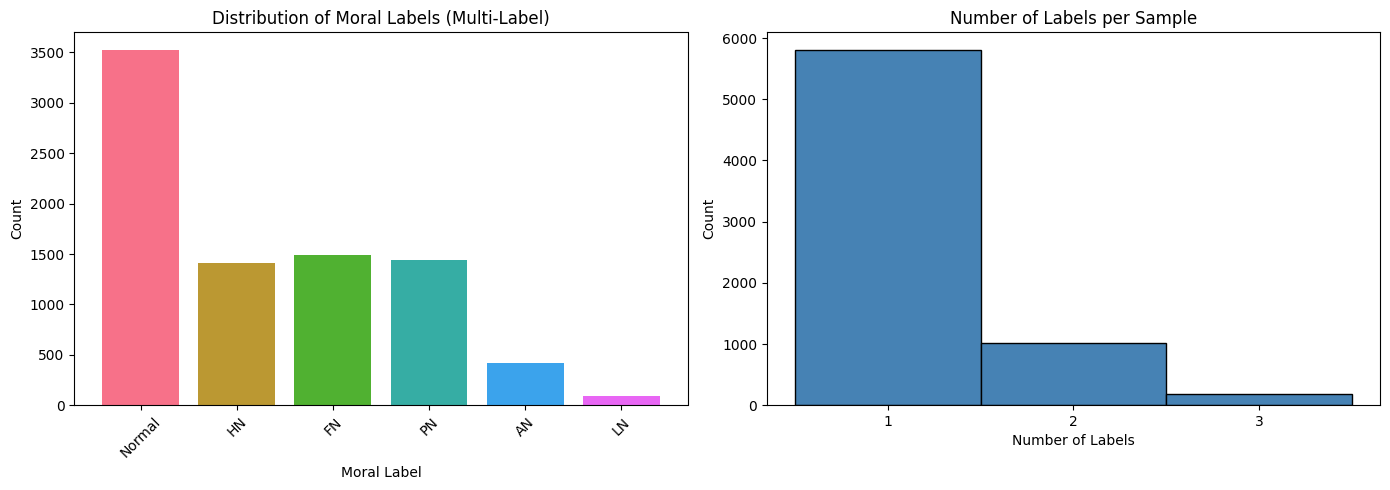

In [ ]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label counts (multi-label)
label_counts = Counter()
for labels in processed_df['labels']:
    for label in labels:
        label_counts[label] += 1

labels_sorted = [l for l in config.LABELS if l in label_counts]
counts = [label_counts[l] for l in labels_sorted]
colors = sns.color_palette('husl', len(labels_sorted))
axes[0].bar(labels_sorted, counts, color=colors)
axes[0].set_xlabel('Moral Label')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Moral Labels (Multi-Label)')
axes[0].tick_params(axis='x', rotation=45)

# Number of labels per sample
num_labels = processed_df['labels'].apply(len)
axes[1].hist(num_labels, bins=range(1, num_labels.max()+2), color='steelblue', edgecolor='black', align='left')
axes[1].set_xlabel('Number of Labels')
axes[1].set_ylabel('Count')
axes[1].set_title('Number of Labels per Sample')
axes[1].set_xticks(range(1, num_labels.max()+1))

plt.tight_layout()
plt.show()

## 4. Ground Truth Attention Generation (Per-Annotator Averaging)

In [ ]:
class AttentionGenerator:
    """
    Generate ground truth attention from human rationales.
    Averages attention masks across annotators (HateXplain methodology).
    """

    def __init__(self, tokenizer, max_length: int = 128, temperature: float = 2.0):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.temperature = temperature

    def find_rationale_tokens(self, text: str, rationales: List[str], encoding) -> np.ndarray:
        """Find which tokens correspond to rationale spans. Returns binary mask."""
        tokens = self.tokenizer.convert_ids_to_tokens(encoding['input_ids'])
        rationale_mask = np.zeros(len(tokens))

        for rationale in rationales:
            rationale_lower = rationale.lower().strip()
            if not rationale_lower:
                continue

            rationale_tokens = self.tokenizer.tokenize(rationale_lower)

            for i in range(len(tokens)):
                if tokens[i] in ['[CLS]', '[SEP]', '[PAD]']:
                    continue

                token_text = tokens[i].replace('##', '').lower()

                for rat_token in rationale_tokens:
                    rat_token_clean = rat_token.replace('##', '').lower()
                    if token_text == rat_token_clean or rat_token_clean in token_text:
                        rationale_mask[i] = 1
                        break

                if rationale_lower and token_text and len(token_text) > 2:
                    if token_text in rationale_lower:
                        rationale_mask[i] = 1

        return rationale_mask

    def generate_attention(self, text: str,
                          annotator1_rationales: List[str],
                          annotator2_rationales: List[str],
                          labels: List[str],
                          encoding) -> np.ndarray:
        """
        Generate ground truth attention by averaging per-annotator masks.
        Following HateXplain Figure 1.
        """
        attention_mask = np.array(encoding['attention_mask'])

        # If Normal (no moral violation), use uniform attention
        if labels == ['Normal']:
            valid_tokens = attention_mask.sum()
            return (attention_mask.astype(float) / valid_tokens).astype(np.float32)

        # Get per-annotator masks
        annotator_masks = []

        if annotator1_rationales:
            mask1 = self.find_rationale_tokens(text, annotator1_rationales, encoding)
            annotator_masks.append(mask1)

        if annotator2_rationales:
            mask2 = self.find_rationale_tokens(text, annotator2_rationales, encoding)
            annotator_masks.append(mask2)

        if not annotator_masks:
            # No rationales found - uniform attention
            valid_tokens = attention_mask.sum()
            return (attention_mask.astype(float) / valid_tokens).astype(np.float32)

        # Average across annotators (HateXplain Figure 1)
        avg_mask = np.mean(annotator_masks, axis=0)

        # Apply softmax with temperature
        scores = avg_mask * self.temperature
        scores = np.where(attention_mask == 1, scores, -1e9)
        exp_scores = np.exp(scores - scores.max())
        gt_attention = exp_scores / exp_scores.sum()

        return gt_attention.astype(np.float32)


# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained(config.MODEL_NAME)
attention_generator = AttentionGenerator(tokenizer, config.MAX_LENGTH, config.TEMPERATURE)

print(f"Tokenizer loaded: {config.MODEL_NAME}")
print(f"Vocabulary size: {tokenizer.vocab_size}")

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

Tokenizer loaded: neuralmind/bert-base-portuguese-cased
Vocabulary size: 29794


## 5. Dataset Class (Multi-Label)

In [ ]:
class MoralXplainDataset(Dataset):
    """PyTorch Dataset for Multi-Label Moral Classification with Rationales"""

    def __init__(self, df: pd.DataFrame, tokenizer, attention_generator,
                 max_length: int = 128, label2id: Dict = None):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.attention_generator = attention_generator
        self.max_length = max_length
        self.label2id = label2id or config.LABEL2ID
        self.num_labels = len(self.label2id)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['text'])
        labels = row['labels'] if isinstance(row['labels'], list) else []
        ann1_rationales = row['annotator1_rationales'] if isinstance(row['annotator1_rationales'], list) else []
        ann2_rationales = row['annotator2_rationales'] if isinstance(row['annotator2_rationales'], list) else []

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        encoding_dict = {
            'input_ids': encoding['input_ids'].squeeze().tolist(),
            'attention_mask': encoding['attention_mask'].squeeze().tolist()
        }

        gt_attention = self.attention_generator.generate_attention(
            text, ann1_rationales, ann2_rationales, labels, encoding_dict
        )

        # Multi-hot encoding for labels
        label_vector = torch.zeros(self.num_labels, dtype=torch.float)
        for label in labels:
            if label in self.label2id:
                label_vector[self.label2id[label]] = 1.0

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': label_vector,  # Multi-hot vector
            'gt_attention': torch.tensor(gt_attention, dtype=torch.float),
            'text': text
        }


def collate_fn(batch):
    return {
        'input_ids': torch.stack([item['input_ids'] for item in batch]),
        'attention_mask': torch.stack([item['attention_mask'] for item in batch]),
        'labels': torch.stack([item['labels'] for item in batch]),
        'gt_attention': torch.stack([item['gt_attention'] for item in batch]),
        'text': [item['text'] for item in batch]
    }

In [ ]:
# Split data (no stratify for multi-label)
train_df, temp_df = train_test_split(
    processed_df,
    test_size=(config.VAL_RATIO + config.TEST_RATIO),
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=config.TEST_RATIO / (config.VAL_RATIO + config.TEST_RATIO),
    random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Create datasets
train_dataset = MoralXplainDataset(train_df, tokenizer, attention_generator, config.MAX_LENGTH)
val_dataset = MoralXplainDataset(val_df, tokenizer, attention_generator, config.MAX_LENGTH)
test_dataset = MoralXplainDataset(test_df, tokenizer, attention_generator, config.MAX_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train: 5600, Val: 700, Test: 700
Batches - Train: 350, Val: 44, Test: 44


## 6. BERT Model with Supervised Attention (Multi-Label)

In [ ]:
class BertForMoralClassification(BertPreTrainedModel):
    """BERT model for multi-label moral classification with supervised attention."""

    def __init__(self, config, num_labels: int = 6):
        super().__init__(config)
        self.num_labels = num_labels
        self.bert = BertModel(config, add_pooling_layer=True)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, num_labels)
        self.init_weights()

    def forward(self, input_ids, attention_mask=None, token_type_ids=None,
                output_attentions=True, return_dict=True):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            output_attentions=output_attentions,
            return_dict=return_dict
        )

        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)  # No sigmoid here - applied in loss/inference

        # Get attention from last layer for CLS token
        # last_attention = outputs.attentions[-1]
        # cls_attention = last_attention[:, :, 0, :].mean(dim=1)
        cls_attention = None
        if output_attentions and outputs.attentions is not None:
          last_attention = outputs.attentions[-1]
          cls_attention = last_attention[:, :, 0, :].mean(dim=1)

        return {
            'logits': logits,
            'attention': cls_attention,
            'all_attentions': outputs.attentions
        }


class BertHateXplainTrainer:
    """
    Trainer implementing HateXplain methodology with attention supervision.
    Uses BCE loss for multi-label and Cross Entropy for attention.
    """

    def __init__(self, model, device, lambda_attention: float = 100):
        self.model = model.to(device)
        self.device = device
        self.lambda_attention = lambda_attention

        # BCE for multi-label classification
        self.classification_loss_fn = nn.BCEWithLogitsLoss()

    def compute_loss(self, batch, use_attention_loss: bool = True):
        input_ids = batch['input_ids'].to(self.device)
        attention_mask = batch['attention_mask'].to(self.device)
        labels = batch['labels'].to(self.device)  # Multi-hot
        gt_attention = batch['gt_attention'].to(self.device)

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True
        )

        logits = outputs['logits']
        pred_attention = outputs['attention']

        # Classification loss (BCE for multi-label)
        cls_loss = self.classification_loss_fn(logits, labels)

        if use_attention_loss:
            # Attention loss - Cross Entropy as per HateXplain paper
            # CE = -sum(gt * log(pred))
            pred_attention = pred_attention.masked_fill(attention_mask == 0, -1e9)
            pred_attention_log = F.log_softmax(pred_attention, dim=-1)
            attn_loss = -torch.sum(gt_attention * pred_attention_log, dim=-1).mean()

            total_loss = cls_loss + self.lambda_attention * attn_loss
        else:
            attn_loss = torch.tensor(0.0)
            total_loss = cls_loss

        return {
            'total_loss': total_loss,
            'cls_loss': cls_loss,
            'attn_loss': attn_loss,
            'logits': logits,
            'attention': pred_attention
        }

In [ ]:
# Initialize models
model_bert = BertForMoralClassification.from_pretrained(
    config.MODEL_NAME,
    num_labels=config.NUM_LABELS
)

model_bert_hatexplain = BertForMoralClassification.from_pretrained(
    config.MODEL_NAME,
    num_labels=config.NUM_LABELS
)

print(f"Models initialized with {config.NUM_LABELS} labels")
print(f"Parameters: {sum(p.numel() for p in model_bert.parameters()):,}")

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForMoralClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForMoralClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Models initialized with 6 labels
Parameters: 108,927,750


## 7. Training Loop (Multi-Label)

In [ ]:
def train_epoch(trainer, train_loader, optimizer, scheduler, use_attention_loss=True):
    trainer.model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in tqdm(train_loader, desc='Training'):
        optimizer.zero_grad()
        outputs = trainer.compute_loss(batch, use_attention_loss=use_attention_loss)
        loss = outputs['total_loss']

        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Multi-label predictions
        probs = torch.sigmoid(outputs['logits'])
        preds = (probs > config.THRESHOLD).int()

        all_preds.append(preds.cpu().numpy())
        all_labels.append(batch['labels'].numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    return {
        'loss': total_loss / len(train_loader),
        'f1_micro': f1_score(all_labels, all_preds, average='micro', zero_division=0),
        'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0)
    }


def evaluate(trainer, data_loader, use_attention_loss=True):
    trainer.model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    all_attentions, all_gt_attentions = [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Evaluating'):
            outputs = trainer.compute_loss(batch, use_attention_loss=use_attention_loss)
            total_loss += outputs['total_loss'].item()

            probs = torch.sigmoid(outputs['logits'])
            preds = (probs > config.THRESHOLD).int()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(batch['labels'].numpy())
            all_probs.append(probs.cpu().numpy())
            all_attentions.extend(outputs['attention'].cpu().numpy())
            all_gt_attentions.extend(batch['gt_attention'].numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    all_probs = np.vstack(all_probs)

    # Multi-label metrics
    exact_match = (all_preds == all_labels).all(axis=1).mean()
    h_loss = hamming_loss(all_labels, all_preds)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_samples = f1_score(all_labels, all_preds, average='samples', zero_division=0)

    try:
        auroc = roc_auc_score(all_labels, all_probs, average='macro')
    except ValueError:
        auroc = 0.0

    return {
        'loss': total_loss / len(data_loader),
        'exact_match': exact_match,
        'hamming_loss': h_loss,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_samples': f1_samples,
        'auroc': auroc,
        'predictions': all_preds,
        'labels': all_labels,
        'probs': all_probs,
        'attentions': np.array(all_attentions),
        'gt_attentions': np.array(all_gt_attentions)
    }

In [ ]:
def train_model(model, train_loader, val_loader, config,
                use_attention_loss=True, model_name="BERT"):
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"Attention Supervision: {use_attention_loss}")
    print(f"{'='*60}\n")

    trainer = BertHateXplainTrainer(model, device, lambda_attention=config.LAMBDA_ATTENTION)
    optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

    total_steps = len(train_loader) * config.NUM_EPOCHS
    warmup_steps = int(total_steps * config.WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = {
        'train_loss': [], 'train_f1_micro': [], 'train_f1_macro': [],
        'val_loss': [], 'val_f1_micro': [], 'val_f1_macro': [],
        'val_exact_match': [], 'val_auroc': []
    }

    best_val_f1 = 0
    best_model_state = None
    patience_counter = 0  # Early stopping counter

    for epoch in range(config.NUM_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{config.NUM_EPOCHS}")

        train_results = train_epoch(trainer, train_loader, optimizer, scheduler, use_attention_loss)
        val_results = evaluate(trainer, val_loader, use_attention_loss)

        print(f"Train - Loss: {train_results['loss']:.4f}, F1-micro: {train_results['f1_micro']:.4f}, F1-macro: {train_results['f1_macro']:.4f}")
        print(f"Val   - Loss: {val_results['loss']:.4f}, F1-micro: {val_results['f1_micro']:.4f}, F1-macro: {val_results['f1_macro']:.4f}")
        print(f"        Exact Match: {val_results['exact_match']:.4f}, Hamming: {val_results['hamming_loss']:.4f}, AUROC: {val_results['auroc']:.4f}")

        # Update history
        history['train_loss'].append(train_results['loss'])
        history['train_f1_micro'].append(train_results['f1_micro'])
        history['train_f1_macro'].append(train_results['f1_macro'])
        history['val_loss'].append(val_results['loss'])
        history['val_f1_micro'].append(val_results['f1_micro'])
        history['val_f1_macro'].append(val_results['f1_macro'])
        history['val_exact_match'].append(val_results['exact_match'])
        history['val_auroc'].append(val_results['auroc'])

        # Early stopping check
        if val_results['f1_macro'] > best_val_f1:
            best_val_f1 = val_results['f1_macro']
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0  # Reset counter
            print(f"  ↑ New best model (F1-macro: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{config.EARLY_STOPPING_PATIENCE})")

            if patience_counter >= config.EARLY_STOPPING_PATIENCE:
                print(f"\n⚠️ Early stopping triggered at epoch {epoch + 1}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return trainer, history

In [ ]:
# Train BERT baseline (without attention supervision)
trainer_bert, history_bert = train_model(
    model_bert, train_loader, val_loader, config,
    use_attention_loss=False, model_name="BERT (Baseline)"
)


Training BERT (Baseline)
Attention Supervision: False


Epoch 1/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


KeyboardInterrupt: 

In [ ]:
torch.save({
    'model_state_dict': trainer_bert.model.state_dict(),
    'config': config.__dict__,
    'history': history_bert
}, '/content/drive/MyDrive/Rationale/model/roberta_baseline_mbert.pt')


In [ ]:
# Save baseline history
with open('/content/drive/MyDrive/Rationale/history/bert_baseline_mbert.json', 'w') as f:
    json.dump(history_bert, f, indent=2)

In [ ]:
# Train BERT-HateXplain (with attention supervision)
trainer_bert_hx, history_bert_hx = train_model(
    model_bert_hatexplain, train_loader, val_loader, config,
    use_attention_loss=True, model_name="BERT-HateXplain"
)


Training BERT-HateXplain
Attention Supervision: True


Epoch 1/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train - Loss: 0.4724, F1-micro: 0.3797, F1-macro: 0.2030
Val   - Loss: 0.3539, F1-micro: 0.5027, F1-macro: 0.1790
        Exact Match: 0.4386, Hamming: 0.1507, AUROC: 0.7160
  ↑ New best model (F1-macro: 0.1790)

Epoch 2/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train - Loss: 0.0078, F1-micro: 0.9987, F1-macro: 0.9969
Val   - Loss: 0.5175, F1-micro: 0.7566, F1-macro: 0.6596
        Exact Match: 0.6614, Hamming: 0.0971, AUROC: 0.8617
  ↑ New best model (F1-macro: 0.6596)

Epoch 20/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train - Loss: 0.0077, F1-micro: 0.9986, F1-macro: 0.9971
Val   - Loss: 0.5120, F1-micro: 0.7530, F1-macro: 0.6599
        Exact Match: 0.6529, Hamming: 0.0995, AUROC: 0.8665
  ↑ New best model (F1-macro: 0.6599)


In [ ]:
torch.save({
    'model_state_dict': trainer_bert_hx.model.state_dict(),
    'config': config.__dict__,
    'history': history_bert_hx
}, '/content/drive/MyDrive/Rationale/model/bert_hatexplain_mbert.pt')


In [ ]:
# Save HateXplain history
with open('/content/drive/MyDrive/Rationale/history/bert_hatexplain_mbert.json', 'w') as f:
    json.dump(history_bert_hx, f, indent=2)

In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_bert = range(1, len(history_bert['train_loss']) + 1)
epochs_hx = range(1, len(history_bert_hx['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(epochs_bert, history_bert['train_loss'], 'b-', label='BERT Train')
axes[0, 0].plot(epochs_bert, history_bert['val_loss'], 'b--', label='BERT Val')
axes[0, 0].plot(epochs_hx, history_bert_hx['train_loss'], 'r-', label='BERT-HX Train')
axes[0, 0].plot(epochs_hx, history_bert_hx['val_loss'], 'r--', label='BERT-HX Val')
axes[0, 0].set_title('Loss'); axes[0, 0].legend()

axes[0, 1].plot(epochs_bert, history_bert['train_f1_macro'], 'b-', label='BERT Train')
axes[0, 1].plot(epochs_bert, history_bert['val_f1_macro'], 'b--', label='BERT Val')
axes[0, 1].plot(epochs_hx, history_bert_hx['train_f1_macro'], 'r-', label='BERT-HX Train')
axes[0, 1].plot(epochs_hx, history_bert_hx['val_f1_macro'], 'r--', label='BERT-HX Val')
axes[0, 1].set_title('F1-Macro'); axes[0, 1].legend()

axes[1, 0].plot(epochs_bert, history_bert['val_exact_match'], 'b--', label='BERT')
axes[1, 0].plot(epochs_hx, history_bert_hx['val_exact_match'], 'r--', label='BERT-HX')
axes[1, 0].set_title('Exact Match Accuracy'); axes[1, 0].legend()

axes[1, 1].plot(epochs_bert, history_bert['val_auroc'], 'b--', label='BERT')
axes[1, 1].plot(epochs_hx, history_bert_hx['val_auroc'], 'r--', label='BERT-HX')
axes[1, 1].set_title('AUROC'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Rationale/lossplots/lambda0point1.png', dpi = 600)
plt.show()

## 8. Explainability Metrics

In [ ]:
class ExplainabilityMetrics:
    """Compute explainability metrics following ERASER benchmark"""

    def __init__(self, top_k: int = 5):
        self.top_k = top_k

    def compute_iou(self, pred_indices, gt_indices):
        pred_set, gt_set = set(pred_indices), set(gt_indices)
        if len(gt_set) == 0:
            return 1.0 if len(pred_set) == 0 else 0.0
        intersection = len(pred_set & gt_set)
        union = len(pred_set | gt_set)
        return intersection / union if union > 0 else 0.0

    def compute_token_f1(self, pred_attn, gt_attn, threshold=0.1):
        pred_binary = (pred_attn > threshold).astype(int)
        uniform_val = 1 / len(gt_attn)
        gt_binary = (gt_attn > uniform_val * 1.5).astype(int)

        if gt_binary.sum() == 0:
            return 1.0 if pred_binary.sum() == 0 else 0.0, 1.0, 1.0
        if pred_binary.sum() == 0:
            return 0.0, 0.0, 0.0

        tp = (pred_binary & gt_binary).sum()
        fp = (pred_binary & ~gt_binary.astype(bool)).sum()
        fn = (~pred_binary.astype(bool) & gt_binary).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        return precision, recall, f1

    def compute_auprc(self, pred_attn, gt_attn):
        uniform_val = 1 / len(gt_attn)
        gt_binary = (gt_attn > uniform_val * 1.5).astype(int)

        if gt_binary.sum() == 0 or gt_binary.sum() == len(gt_binary):
            return 1.0

        try:
            precision, recall, _ = precision_recall_curve(gt_binary, pred_attn)
            return auc(recall, precision)
        except:
            return 0.0

    def compute_iou_f1(self, pred_attns, gt_attns, iou_threshold=0.5):
        matches, total = 0, 0
        for pred_attn, gt_attn in zip(pred_attns, gt_attns):
            pred_indices = pred_attn.argsort()[-self.top_k:][::-1]
            uniform_val = 1 / len(gt_attn)
            gt_indices = np.where(gt_attn > uniform_val * 1.5)[0]

            if len(gt_indices) == 0:
                continue

            iou = self.compute_iou(pred_indices, gt_indices)
            if iou >= iou_threshold:
                matches += 1
            total += 1

        return matches / total if total > 0 else 0.0

    def compute_all(self, pred_attns, gt_attns):
        iou_f1 = self.compute_iou_f1(pred_attns, gt_attns)

        all_f1s, all_auprcs = [], []
        for pred_attn, gt_attn in zip(pred_attns, gt_attns):
            pred_norm = (pred_attn - pred_attn.min()) / (pred_attn.max() - pred_attn.min() + 1e-8)
            _, _, f1 = self.compute_token_f1(pred_norm, gt_attn)
            auprc = self.compute_auprc(pred_norm, gt_attn)
            all_f1s.append(f1)
            all_auprcs.append(auprc)

        return {
            'iou_f1': iou_f1,
            'token_f1': np.mean(all_f1s),
            'auprc': np.mean(all_auprcs)
        }

explainability = ExplainabilityMetrics(top_k=config.TOP_K_RATIONALES)

In [ ]:
class FaithfulnessMetrics:
    """Compute Comprehensiveness and Sufficiency for multi-label."""

    def __init__(self, model, tokenizer, device, top_k=5, threshold=0.5):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.top_k = top_k
        self.threshold = threshold

    def get_probs(self, input_ids, attention_mask):
        """Get sigmoid probabilities for all classes."""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=True
            )
            probs = torch.sigmoid(outputs['logits'])
            return probs[0].cpu().numpy()

    def compute_comprehensiveness(self, input_ids, attention_mask, rationale_idx):
        """Comprehensiveness: average prob drop across positive classes."""
        original_probs = self.get_probs(input_ids, attention_mask)

        masked_ids = input_ids.clone()
        for idx in rationale_idx:
            if idx < len(masked_ids):
                masked_ids[idx] = self.tokenizer.mask_token_id
        masked_probs = self.get_probs(masked_ids, attention_mask)

        # Average over positive predictions
        positive_mask = original_probs > self.threshold
        if positive_mask.sum() == 0:
            return 0.0

        prob_drops = original_probs - masked_probs
        return prob_drops[positive_mask].mean()

    def compute_sufficiency(self, input_ids, attention_mask, rationale_idx):
        """Sufficiency: average prob drop when keeping only rationales."""
        original_probs = self.get_probs(input_ids, attention_mask)

        masked_ids = input_ids.clone()
        rationale_set = set(rationale_idx.tolist())

        for idx in range(len(masked_ids)):
            token = self.tokenizer.convert_ids_to_tokens([masked_ids[idx].item()])[0]
            if token in ['[CLS]', '[SEP]', '[PAD]']:
                continue
            if idx not in rationale_set:
                masked_ids[idx] = self.tokenizer.mask_token_id

        rationale_probs = self.get_probs(masked_ids, attention_mask)

        positive_mask = original_probs > self.threshold
        if positive_mask.sum() == 0:
            return 0.0

        prob_drops = original_probs - rationale_probs
        return prob_drops[positive_mask].mean()

    def compute_all(self, data_loader, attentions):
        comp_scores, suff_scores = [], []
        self.model.eval()
        idx = 0

        for batch in tqdm(data_loader, desc='Faithfulness'):
            for i in range(batch['input_ids'].size(0)):
                if idx >= len(attentions):
                    break

                input_ids = batch['input_ids'][i]
                attention_mask = batch['attention_mask'][i]
                rationale_idx = attentions[idx].argsort()[-self.top_k:][::-1]

                comp = self.compute_comprehensiveness(input_ids, attention_mask, rationale_idx)
                suff = self.compute_sufficiency(input_ids, attention_mask, rationale_idx)

                comp_scores.append(comp)
                suff_scores.append(suff)
                idx += 1

        return {
            'comprehensiveness': np.mean(comp_scores),
            'sufficiency': np.mean(suff_scores)
        }

In [ ]:
# update faithfulness
class FaithfulnessMetrics:
    """
    Compute Comprehensiveness and Sufficiency following ERASER benchmark.

    Reference: DeYoung et al. "ERASER: A Benchmark to Evaluate Rationalized NLP Models"
    https://arxiv.org/abs/1911.03429

    Comprehensiveness: p(y|x) - p(y|x \ r)
        - Remove rationale tokens, measure probability drop
        - Higher = rationales are important for prediction

    Sufficiency: p(y|x) - p(y|r)
        - Keep ONLY rationale tokens, measure probability drop
        - Lower = rationales alone are sufficient
    """

    def __init__(self, model, tokenizer, device, top_k=5, threshold=0.5):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.top_k = top_k
        self.threshold = threshold

    def get_predicted_class_prob(self, input_ids, attention_mask, class_indices):
        """
        Get probability for specific class(es).
        For multi-label: returns mean prob across specified classes.
        """
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False  # Don't need attention here
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()

            if len(class_indices) == 0:
                return 0.0

            return probs[class_indices].mean()

    def get_predicted_classes(self, input_ids, attention_mask):
        """Get indices of predicted positive classes."""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()
            return np.where(probs > self.threshold)[0]

    def create_masked_input(self, input_ids, indices_to_mask):
        """Replace specified indices with [MASK] token."""
        masked_ids = input_ids.clone()
        for idx in indices_to_mask:
            if 0 <= idx < len(masked_ids):
                token = self.tokenizer.convert_ids_to_tokens([masked_ids[idx].item()])[0]
                if token not in ['[CLS]', '[SEP]', '[PAD]']:
                    masked_ids[idx] = self.tokenizer.mask_token_id
        return masked_ids

    def compute_comprehensiveness(self, input_ids, attention_mask, rationale_indices, pred_classes):
        """
        Comprehensiveness = p(y|x) - p(y|x \ r)

        Measures how much the prediction changes when rationales are REMOVED.
        Higher value = rationales are more important.
        """
        if len(pred_classes) == 0:
            return 0.0

        # p(y|x) - original probability
        original_prob = self.get_predicted_class_prob(input_ids, attention_mask, pred_classes)

        # p(y|x \ r) - probability after removing rationales
        masked_ids = self.create_masked_input(input_ids, rationale_indices)
        masked_prob = self.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)

        # Comprehensiveness = original - masked (should be positive if rationales matter)
        return float(original_prob - masked_prob)

    def compute_sufficiency(self, input_ids, attention_mask, rationale_indices, pred_classes):
        """
        Sufficiency = p(y|x) - p(y|r)

        Measures how sufficient the rationales alone are for prediction.
        Lower value = rationales alone are sufficient.
        """
        if len(pred_classes) == 0:
            return 0.0

        # p(y|x) - original probability
        original_prob = self.get_predicted_class_prob(input_ids, attention_mask, pred_classes)

        # p(y|r) - probability with ONLY rationales (mask everything else)
        rationale_set = set(rationale_indices.tolist() if hasattr(rationale_indices, 'tolist') else rationale_indices)

        # Find all non-special token indices to mask
        indices_to_mask = []
        for idx in range(len(input_ids)):
            token = self.tokenizer.convert_ids_to_tokens([input_ids[idx].item()])[0]
            if token in ['[CLS]', '[SEP]', '[PAD]']:
                continue
            if idx not in rationale_set:
                indices_to_mask.append(idx)

        masked_ids = self.create_masked_input(input_ids, indices_to_mask)
        rationale_only_prob = self.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)

        # Sufficiency = original - rationale_only (lower is better)
        return float(original_prob - rationale_only_prob)

    def select_rationale_indices(self, attention_weights, attention_mask, method='topk'):
        """
        Select rationale token indices from attention weights.

        Methods:
        - 'topk': Select top-k highest attention tokens
        - 'threshold': Select tokens above mean + std attention
        """
        # Mask out padding tokens
        valid_attention = attention_weights.copy()
        valid_attention[attention_mask == 0] = -np.inf

        # Also ignore [CLS] (index 0) and [SEP] tokens for rationale selection
        valid_attention[0] = -np.inf  # [CLS]

        if method == 'topk':
            # Get top-k indices
            indices = valid_attention.argsort()[-self.top_k:][::-1]
            # Filter out any invalid indices
            indices = [i for i in indices if valid_attention[i] > -np.inf]
        else:  # threshold method
            threshold = valid_attention[valid_attention > -np.inf].mean() + \
                       valid_attention[valid_attention > -np.inf].std()
            indices = np.where(valid_attention > threshold)[0]

        return np.array(indices)

    def compute_all(self, data_loader, attentions):
        """
        Compute comprehensiveness and sufficiency over entire dataset.

        Args:
            data_loader: DataLoader with test data
            attentions: Model attention weights for each sample

        Returns:
            Dict with mean comprehensiveness and sufficiency scores
        """
        comp_scores = []
        suff_scores = []
        self.model.eval()
        idx = 0

        for batch in tqdm(data_loader, desc='Computing Faithfulness'):
            batch_size = batch['input_ids'].size(0)

            for i in range(batch_size):
                if idx >= len(attentions):
                    break

                input_ids = batch['input_ids'][i]
                attention_mask = batch['attention_mask'][i].numpy()
                attention_weights = attentions[idx]

                # Get predicted classes for this sample
                pred_classes = self.get_predicted_classes(input_ids, batch['attention_mask'][i])

                # Select rationale indices from attention
                rationale_indices = self.select_rationale_indices(
                    attention_weights, attention_mask, method='topk'
                )

                # Skip if no rationales selected or no predictions
                if len(rationale_indices) == 0 or len(pred_classes) == 0:
                    idx += 1
                    continue

                # Compute metrics
                comp = self.compute_comprehensiveness(
                    input_ids, batch['attention_mask'][i], rationale_indices, pred_classes
                )
                suff = self.compute_sufficiency(
                    input_ids, batch['attention_mask'][i], rationale_indices, pred_classes
                )

                comp_scores.append(comp)
                suff_scores.append(suff)
                idx += 1

        return {
            'comprehensiveness': np.mean(comp_scores) if comp_scores else 0.0,
            'sufficiency': np.mean(suff_scores) if suff_scores else 0.0,
            'num_samples': len(comp_scores)
        }

## 9. Final Evaluation

In [ ]:
def full_evaluation(trainer, test_loader, tokenizer, model_name, use_attention_loss=True):
    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*60}\n")

    results = evaluate(trainer, test_loader, use_attention_loss)

    print("Performance (Multi-Label):")
    print(f"  Exact Match Accuracy: {results['exact_match']:.4f}")
    print(f"  Hamming Loss: {results['hamming_loss']:.4f}")
    print(f"  F1-Micro: {results['f1_micro']:.4f}")
    print(f"  F1-Macro: {results['f1_macro']:.4f}")
    print(f"  F1-Samples: {results['f1_samples']:.4f}")
    print(f"  AUROC: {results['auroc']:.4f}")

    print(f"\nPer-Label Classification Report:")
    print(classification_report(
        results['labels'],
        results['predictions'],
        target_names=config.LABELS,
        zero_division=0
    ))

    plausibility = explainability.compute_all(results['attentions'], results['gt_attentions'])
    print("\nPlausibility:")
    print(f"  IOU F1: {plausibility['iou_f1']:.4f}")
    print(f"  Token F1: {plausibility['token_f1']:.4f}")
    print(f"  AUPRC: {plausibility['auprc']:.4f}")

    faithfulness_calc = FaithfulnessMetrics(
        trainer.model, tokenizer, device,
        config.TOP_K_RATIONALES, config.THRESHOLD
    )
    faithfulness = faithfulness_calc.compute_all(test_loader, results['attentions'])
    print("\nFaithfulness:")
    print(f"  Comprehensiveness: {faithfulness['comprehensiveness']:.4f} (↑ better)")
    print(f"  Sufficiency: {faithfulness['sufficiency']:.4f} (↓ better)")

    return {
        'performance': {
            'exact_match': results['exact_match'],
            'hamming_loss': results['hamming_loss'],
            'f1_micro': results['f1_micro'],
            'f1_macro': results['f1_macro'],
            'f1_samples': results['f1_samples'],
            'auroc': results['auroc']
        },
        'plausibility': plausibility,
        'faithfulness': faithfulness,
        'predictions': results['predictions'],
        'labels': results['labels'],
        'attentions': results['attentions']
    }

In [ ]:
eval_bert = full_evaluation(trainer_bert, test_loader, tokenizer, "BERT", use_attention_loss=False)

NameError: name 'trainer_bert' is not defined

In [ ]:
eval_bert_hx = full_evaluation(trainer_bert_hx, test_loader, tokenizer, "BERT-HateXplain", use_attention_loss=True)

In [ ]:
# Comparison table
comparison = pd.DataFrame({
    'Metric': [
        'Exact Match ↑', 'Hamming Loss ↓', 'F1-Micro ↑', 'F1-Macro ↑', 'AUROC ↑',
        'IOU F1 ↑', 'Token F1 ↑', 'AUPRC ↑',
        'Comprehensiveness ↑', 'Sufficiency ↓'
    ],
    'BERT': [
        eval_bert['performance']['exact_match'],
        eval_bert['performance']['hamming_loss'],
        eval_bert['performance']['f1_micro'],
        eval_bert['performance']['f1_macro'],
        eval_bert['performance']['auroc'],
        eval_bert['plausibility']['iou_f1'],
        eval_bert['plausibility']['token_f1'],
        eval_bert['plausibility']['auprc'],
        eval_bert['faithfulness']['comprehensiveness'],
        eval_bert['faithfulness']['sufficiency']
    ],
    'BERT-HateXplain': [
        eval_bert_hx['performance']['exact_match'],
        eval_bert_hx['performance']['hamming_loss'],
        eval_bert_hx['performance']['f1_micro'],
        eval_bert_hx['performance']['f1_macro'],
        eval_bert_hx['performance']['auroc'],
        eval_bert_hx['plausibility']['iou_f1'],
        eval_bert_hx['plausibility']['token_f1'],
        eval_bert_hx['plausibility']['auprc'],
        eval_bert_hx['faithfulness']['comprehensiveness'],
        eval_bert_hx['faithfulness']['sufficiency']
    ]
}).round(4)

print("\nModel Comparison:")
display(comparison)

In [ ]:
# Per-label performance visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate per-label F1 for both models
from sklearn.metrics import f1_score

bert_f1_per_label = f1_score(eval_bert['labels'], eval_bert['predictions'], average=None, zero_division=0)
bert_hx_f1_per_label = f1_score(eval_bert_hx['labels'], eval_bert_hx['predictions'], average=None, zero_division=0)

x = np.arange(len(config.LABELS))
width = 0.35

axes[0].bar(x - width/2, bert_f1_per_label, width, label='BERT', color='steelblue')
axes[0].bar(x + width/2, bert_hx_f1_per_label, width, label='BERT-HX', color='coral')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Per-Label F1 Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(config.LABELS, rotation=45)
axes[0].legend()

# Label co-occurrence heatmap
co_occurrence = np.zeros((len(config.LABELS), len(config.LABELS)))
for labels in processed_df['labels']:
    for l1 in labels:
        for l2 in labels:
            if l1 in config.LABEL2ID and l2 in config.LABEL2ID:
                co_occurrence[config.LABEL2ID[l1], config.LABEL2ID[l2]] += 1

sns.heatmap(co_occurrence, annot=True, fmt='.0f', cmap='Blues', ax=axes[1],
            xticklabels=config.LABELS, yticklabels=config.LABELS)
axes[1].set_title('Label Co-occurrence Matrix')

plt.tight_layout()
plt.show()

## 10. Save Models

In [ ]:
os.makedirs('models', exist_ok=True)

torch.save({
    'model_state_dict': trainer_bert.model.state_dict(),
    'config': config.__dict__,
    'history': history_bert
}, '/content/drive/MyDrive/Rationale/model/bert_baseline_multilabel.pt')

torch.save({
    'model_state_dict': trainer_bert_hx.model.state_dict(),
    'config': config.__dict__,
    'history': history_bert_hx
}, '/content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel.pt')

print("Models saved!")

Models saved!


RUN EVAL From SAVED MODEL

In [ ]:
def load_model_and_evaluate(model_path, test_loader, tokenizer, model_name, use_attention_loss=True):
    """Load saved model and run full evaluation."""

    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    # Initialize model architecture
    model = BertForMoralClassification.from_pretrained(
        config.MODEL_NAME,
        num_labels=config.NUM_LABELS
    )

    # Load saved weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    # Create trainer wrapper
    trainer = BertHateXplainTrainer(model, device, lambda_attention=config.LAMBDA_ATTENTION)

    # Run evaluation
    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"Model loaded from: {model_path}")
    print(f"{'='*60}\n")

    results = evaluate(trainer, test_loader, use_attention_loss)

    print("Performance (Multi-Label):")
    print(f"  Exact Match Accuracy: {results['exact_match']:.4f}")
    print(f"  Hamming Loss: {results['hamming_loss']:.4f}")
    print(f"  F1-Micro: {results['f1_micro']:.4f}")
    print(f"  F1-Macro: {results['f1_macro']:.4f}")
    print(f"  F1-Samples: {results['f1_samples']:.4f}")
    print(f"  AUROC: {results['auroc']:.4f}")

    print(f"\nPer-Label Classification Report:")
    print(classification_report(
        results['labels'],
        results['predictions'],
        target_names=config.LABELS,
        zero_division=0, digits = 4
    ))

    plausibility = explainability.compute_all(results['attentions'], results['gt_attentions'])
    print("\nPlausibility:")
    print(f"  IOU F1: {plausibility['iou_f1']:.4f}")
    print(f"  Token F1: {plausibility['token_f1']:.4f}")
    print(f"  AUPRC: {plausibility['auprc']:.4f}")

    faithfulness_calc = FaithfulnessMetrics(
        trainer.model, tokenizer, device,
        config.TOP_K_RATIONALES, config.THRESHOLD, ratio = 0.75
    )
    faithfulness = faithfulness_calc.compute_all(test_loader, results['attentions'])
    print("\nFaithfulness:")
    print(f"  Comprehensiveness: {faithfulness['comprehensiveness']:.4f} (↑ better)")
    print(f"  Sufficiency: {faithfulness['sufficiency']:.4f} (↓ better)")

    return {
        'performance': {
            'exact_match': results['exact_match'],
            'hamming_loss': results['hamming_loss'],
            'f1_micro': results['f1_micro'],
            'f1_macro': results['f1_macro'],
            'f1_samples': results['f1_samples'],
            'auroc': results['auroc']
        },
        'plausibility': plausibility,
        'faithfulness': faithfulness,
        'predictions': results['predictions'],
        'labels': results['labels'],
        'attentions': results['attentions']
    }

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

class BiasMetrics:
    """
    Compute bias metrics following Borkan et al. (2019) and HateXplain.

    Reference: "Nuanced Metrics for Measuring Unintended Bias with Real Data for Text Classification"
    https://arxiv.org/abs/1903.04561
    """

    def __init__(self, identity_terms=None):
        """
        Args:
            identity_terms: Dict mapping identity group to list of terms
        """
        # Default identity terms (adapt for Portuguese if needed)
        # self.identity_terms = identity_terms or {
        #     'gender': ['mulher', 'homem', 'feminista', 'gay', 'lésbica', 'trans', 'viado', 'sapatão'],
        #     'race': ['negro', 'negra', 'preto', 'preta', 'branco', 'índio', 'macaco'],
        #     'religion': ['cristão', 'evangélico', 'católico', 'muçulmano', 'judeu', 'ateu'],
        #     'politics': ['bolsonaro', 'lula', 'petista', 'bolsonarista', 'esquerda', 'direita'],
        #     'nationality': ['brasileiro', 'nordestino', 'gringo', 'imigrante']
        # }
        self.identity_terms = identity_terms or {
              "female_gender": ["mulher", "mulheres", "vagabunda", "quenga", "puta", "vadia", "piranha", "feminista", "bruxa", "ninfeta", "rapariga", "cachorra", "cachorrona", "quenga", "galinha", "cadela"],
              "male_gender": ["homem", "homens", "viado", "bicha", "maricas"],
              "race_ethnicity": ["preto", "negra", "negão", "branco", "racista", "macaco", "macaca", "chita", "nordestino", "nordestinos", "judeu", "jornazista", "hipocristão", "macumbeira", "macumbeiro", "pastor"],
              "sexual_orientation": ["gay", "viado", "lésbica", "sapatão", "homossexual", "sapatona", "bicha", "veado"],
              "political_identity": ["comunista", "socialista", "esquerdista", "bolsonarista", "petista", "fascista", "petralha", "esquerda", "direita", "socialista", "bozo", "minions", "chauvinista", "petzadas", "ptzada", "pretalhas", "vermelhada"],
              "fatphobia": ["peppa", "pepa", "pepinha", "gorda", "gordo", "barriguda", "barrigudo", "porca", "porco", "roliça", "roliço", "vaca", "boi"],
              }

    def identify_subgroup(self, text, group_terms):
        """Check if text contains any term from the group."""
        text_lower = text.lower()
        return any(term in text_lower for term in group_terms)

    def get_subgroup_mask(self, texts, group_terms):
        """Get boolean mask for samples containing subgroup terms."""
        return np.array([self.identify_subgroup(t, group_terms) for t in texts])

    def compute_subgroup_auc(self, y_true, y_pred_proba, subgroup_mask):
        """
        Subgroup AUC: AUC computed only on subgroup samples.
        Measures how well model distinguishes positive/negative within subgroup.
        """
        if subgroup_mask.sum() < 5:  # Not enough samples
            return None

        y_true_sub = y_true[subgroup_mask]
        y_pred_sub = y_pred_proba[subgroup_mask]

        # Need both classes present
        if len(np.unique(y_true_sub)) < 2:
            return None

        try:
            return roc_auc_score(y_true_sub, y_pred_sub)
        except:
            return None

    def compute_bpsn_auc(self, y_true, y_pred_proba, subgroup_mask):
        """
        BPSN (Background Positive, Subgroup Negative) AUC.

        Compares:
        - Positive samples NOT in subgroup (background positive)
        - Negative samples IN subgroup (subgroup negative)

        Low score = model over-predicts positive for subgroup negatives (bias!)
        """
        # Background positive: y=1 and not in subgroup
        bg_pos_mask = (y_true == 1) & (~subgroup_mask)
        # Subgroup negative: y=0 and in subgroup
        sub_neg_mask = (y_true == 0) & subgroup_mask

        combined_mask = bg_pos_mask | sub_neg_mask

        if combined_mask.sum() < 5:
            return None

        y_true_combined = y_true[combined_mask]
        y_pred_combined = y_pred_proba[combined_mask]

        if len(np.unique(y_true_combined)) < 2:
            return None

        try:
            return roc_auc_score(y_true_combined, y_pred_combined)
        except:
            return None

    def compute_bnsp_auc(self, y_true, y_pred_proba, subgroup_mask):
        """
        BNSP (Background Negative, Subgroup Positive) AUC.

        Compares:
        - Negative samples NOT in subgroup (background negative)
        - Positive samples IN subgroup (subgroup positive)

        Low score = model under-predicts positive for subgroup positives (bias!)
        """
        # Background negative: y=0 and not in subgroup
        bg_neg_mask = (y_true == 0) & (~subgroup_mask)
        # Subgroup positive: y=1 and in subgroup
        sub_pos_mask = (y_true == 1) & subgroup_mask

        combined_mask = bg_neg_mask | sub_pos_mask

        if combined_mask.sum() < 5:
            return None

        y_true_combined = y_true[combined_mask]
        y_pred_combined = y_pred_proba[combined_mask]

        if len(np.unique(y_true_combined)) < 2:
            return None

        try:
            return roc_auc_score(y_true_combined, y_pred_combined)
        except:
            return None

    def generalized_mean(self, values, p=-5):
        """
        Generalized mean with power p.
        p=-5 emphasizes lower values (worse bias).
        """
        values = [v for v in values if v is not None]
        if not values:
            return None

        values = np.array(values)
        return np.power(np.mean(np.power(values, p)), 1/p)

    def compute_all(self, texts, y_true, y_pred_proba):
        """
        Compute all bias metrics.

        Args:
            texts: List of original text strings
            y_true: Ground truth labels (binary: 0=Normal, 1=Hate/Offensive)
            y_pred_proba: Predicted probabilities for positive class

        Returns:
            Dict with all bias metrics
        """
        results = {
            'per_group': {},
            'GMB_Subgroup': None,
            'GMB_BPSN': None,
            'GMB_BNSP': None
        }

        all_subgroup_aucs = []
        all_bpsn_aucs = []
        all_bnsp_aucs = []

        for group_name, group_terms in self.identity_terms.items():
            subgroup_mask = self.get_subgroup_mask(texts, group_terms)
            n_samples = subgroup_mask.sum()

            if n_samples < 10:
                print(f"  {group_name}: Skipped (only {n_samples} samples)")
                continue

            sub_auc = self.compute_subgroup_auc(y_true, y_pred_proba, subgroup_mask)
            bpsn_auc = self.compute_bpsn_auc(y_true, y_pred_proba, subgroup_mask)
            bnsp_auc = self.compute_bnsp_auc(y_true, y_pred_proba, subgroup_mask)

            results['per_group'][group_name] = {
                'n_samples': int(n_samples),
                'subgroup_auc': sub_auc,
                'bpsn_auc': bpsn_auc,
                'bnsp_auc': bnsp_auc
            }

            if sub_auc is not None:
                all_subgroup_aucs.append(sub_auc)
            if bpsn_auc is not None:
                all_bpsn_aucs.append(bpsn_auc)
            if bnsp_auc is not None:
                all_bnsp_aucs.append(bnsp_auc)

            print(f"  {group_name}: n={n_samples}, SubAUC={sub_auc:.4f if sub_auc else 'N/A'}, "
                  f"BPSN={bpsn_auc:.4f if bpsn_auc else 'N/A'}, BNSP={bnsp_auc:.4f if bnsp_auc else 'N/A'}")

        # Compute generalized means
        results['GMB_Subgroup'] = self.generalized_mean(all_subgroup_aucs)
        results['GMB_BPSN'] = self.generalized_mean(all_bpsn_aucs)
        results['GMB_BNSP'] = self.generalized_mean(all_bnsp_aucs)

        return results

In [ ]:
class BiasMetrics:
    """
    Compute bias metrics following Borkan et al. (2019) and HateXplain.
    """

    def __init__(self, identity_terms=None):
        # Default identity terms for Portuguese
        # self.identity_terms = identity_terms or
        # self.identity_terms = identity_terms or {
        #     'gender': ['mulher', 'homem', 'feminista', 'gay', 'lésbica', 'trans', 'viado', 'sapatão'],
        #     'race': ['negro', 'negra', 'preto', 'preta', 'branco', 'índio', 'macaco'],
        #     'religion': ['cristão', 'evangélico', 'católico', 'muçulmano', 'judeu', 'ateu'],
        #     'politics': ['bolsonaro', 'lula', 'petista', 'bolsonarista', 'esquerda', 'direita'],
        #     'nationality': ['brasileiro', 'nordestino', 'gringo', 'imigrante']
        # }
        self.identity_terms = identity_terms or {
              "female_gender": ["mulher", "mulheres", "vagabunda", "quenga", "puta", "vadia", "piranha", "feminista", "bruxa", "ninfeta", "rapariga", "cachorra", "cachorrona", "quenga", "galinha", "cadela"],
              "male_gender": ["homem", "homens", "viado", "bicha", "maricas"],
              "race_ethnicity": ["preto", "negra", "negão", "branco", "racista", "macaco", "macaca", "chita", "nordestino", "nordestinos", "judeu", "jornazista", "hipocristão", "macumbeira", "macumbeiro", "pastor"],
              "sexual_orientation": ["gay", "viado", "lésbica", "sapatão", "homossexual", "sapatona", "bicha", "veado"],
              "political_identity": ["comunista", "socialista", "esquerdista", "bolsonarista", "petista", "fascista", "petralha", "esquerda", "direita", "socialista", "bozo", "minions", "chauvinista", "petzadas", "ptzada", "pretalhas", "vermelhada"],
              "fatphobia": ["peppa", "pepa", "pepinha", "gorda", "gordo", "barriguda", "barrigudo", "porca", "porco", "roliça", "roliço", "vaca", "boi"],
              }

    def identify_subgroup(self, text, group_terms):
        """Check if text contains any term from the group."""
        text_lower = text.lower()
        return any(term in text_lower for term in group_terms)

    def get_subgroup_mask(self, texts, group_terms):
        """Get boolean mask for samples containing subgroup terms."""
        return np.array([self.identify_subgroup(t, group_terms) for t in texts])

    def compute_subgroup_auc(self, y_true, y_pred_proba, subgroup_mask):
        """Subgroup AUC: AUC computed only on subgroup samples."""
        if subgroup_mask.sum() < 5:
            return None

        y_true_sub = y_true[subgroup_mask]
        y_pred_sub = y_pred_proba[subgroup_mask]

        if len(np.unique(y_true_sub)) < 2:
            return None

        try:
            return roc_auc_score(y_true_sub, y_pred_sub)
        except:
            return None

    def compute_bpsn_auc(self, y_true, y_pred_proba, subgroup_mask):
        """BPSN (Background Positive, Subgroup Negative) AUC."""
        bg_pos_mask = (y_true == 1) & (~subgroup_mask)
        sub_neg_mask = (y_true == 0) & subgroup_mask

        combined_mask = bg_pos_mask | sub_neg_mask

        if combined_mask.sum() < 5:
            return None

        y_true_combined = y_true[combined_mask]
        y_pred_combined = y_pred_proba[combined_mask]

        if len(np.unique(y_true_combined)) < 2:
            return None

        try:
            return roc_auc_score(y_true_combined, y_pred_combined)
        except:
            return None

    def compute_bnsp_auc(self, y_true, y_pred_proba, subgroup_mask):
        """BNSP (Background Negative, Subgroup Positive) AUC."""
        bg_neg_mask = (y_true == 0) & (~subgroup_mask)
        sub_pos_mask = (y_true == 1) & subgroup_mask

        combined_mask = bg_neg_mask | sub_pos_mask

        if combined_mask.sum() < 5:
            return None

        y_true_combined = y_true[combined_mask]
        y_pred_combined = y_pred_proba[combined_mask]

        if len(np.unique(y_true_combined)) < 2:
            return None

        try:
            return roc_auc_score(y_true_combined, y_pred_combined)
        except:
            return None

    def generalized_mean(self, values, p=-5):
        """Generalized mean with power p."""
        values = [v for v in values if v is not None]
        if not values:
            return None

        values = np.array(values)
        return np.power(np.mean(np.power(values, p)), 1/p)

    def format_score(self, score):
        """Format score for printing."""
        if score is None:
            return 'N/A'
        return f"{score:.4f}"

    def compute_all(self, texts, y_true, y_pred_proba):
        """Compute all bias metrics."""
        results = {
            'per_group': {},
            'GMB_Subgroup': None,
            'GMB_BPSN': None,
            'GMB_BNSP': None
        }

        all_subgroup_aucs = []
        all_bpsn_aucs = []
        all_bnsp_aucs = []

        for group_name, group_terms in self.identity_terms.items():
            subgroup_mask = self.get_subgroup_mask(texts, group_terms)
            n_samples = subgroup_mask.sum()

            if n_samples < 10:
                print(f"  {group_name}: Skipped (only {n_samples} samples)")
                continue

            sub_auc = self.compute_subgroup_auc(y_true, y_pred_proba, subgroup_mask)
            bpsn_auc = self.compute_bpsn_auc(y_true, y_pred_proba, subgroup_mask)
            bnsp_auc = self.compute_bnsp_auc(y_true, y_pred_proba, subgroup_mask)

            results['per_group'][group_name] = {
                'n_samples': int(n_samples),
                'subgroup_auc': sub_auc,
                'bpsn_auc': bpsn_auc,
                'bnsp_auc': bnsp_auc
            }

            if sub_auc is not None:
                all_subgroup_aucs.append(sub_auc)
            if bpsn_auc is not None:
                all_bpsn_aucs.append(bpsn_auc)
            if bnsp_auc is not None:
                all_bnsp_aucs.append(bnsp_auc)

            # Fixed print statement
            sub_str = self.format_score(sub_auc)
            bpsn_str = self.format_score(bpsn_auc)
            bnsp_str = self.format_score(bnsp_auc)
            print(f"  {group_name}: n={n_samples}, SubAUC={sub_str}, BPSN={bpsn_str}, BNSP={bnsp_str}")

        # Compute generalized means
        results['GMB_Subgroup'] = self.generalized_mean(all_subgroup_aucs)
        results['GMB_BPSN'] = self.generalized_mean(all_bpsn_aucs)
        results['GMB_BNSP'] = self.generalized_mean(all_bnsp_aucs)

        return results

In [ ]:
test_texts = test_df['text'].tolist()


In [ ]:
def compute_bias_metrics(trainer, test_loader, test_texts, model_name):
    """Compute bias metrics for a model."""

    print(f"\n{'='*60}")
    print(f"Bias Metrics: {model_name}")
    print(f"{'='*60}\n")

    # Get predictions
    trainer.model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Getting predictions"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = trainer.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_attentions=False
            )

            probs = torch.sigmoid(outputs['logits']).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(batch['labels'].numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    # For bias metrics, convert multi-label to binary (Normal vs Any Hate)
    # Normal is index 0, so "hate" = any non-Normal label
    y_true_binary = (all_labels[:, 1:].sum(axis=1) > 0).astype(int)  # 1 if any hate label
    y_pred_proba = 1 - all_probs[:, 0]  # P(hate) = 1 - P(normal)

    print(f"Binary labels: {y_true_binary.sum()} hate, {len(y_true_binary) - y_true_binary.sum()} normal")

    # Compute bias metrics
    bias_calc = BiasMetrics()
    bias_results = bias_calc.compute_all(test_texts, y_true_binary, y_pred_proba)

    print(f"\n{'='*40}")
    print("Generalized Mean of Bias (GMB) Scores:")
    print(f"{'='*40}")
    print(f"  GMB-Subgroup: {bias_results['GMB_Subgroup']:.4f if bias_results['GMB_Subgroup'] else 'N/A'}")
    print(f"  GMB-BPSN:     {bias_results['GMB_BPSN']:.4f if bias_results['GMB_BPSN'] else 'N/A'}")
    print(f"  GMB-BNSP:     {bias_results['GMB_BNSP']:.4f if bias_results['GMB_BNSP'] else 'N/A'}")

    return bias_results


# Get test texts
test_texts = test_df['text'].tolist()

# Compute for each model
bias_bert = compute_bias_metrics(trainer_bert, test_loader, test_texts, "BERT Baseline")
bias_bert_hx = compute_bias_metrics(trainer_bert_hx, test_loader, test_texts, "BERT-HateXplain")

NameError: name 'trainer_bert' is not defined

In [ ]:
test_texts = test_df['text'].tolist()


In [ ]:
class BiasMetricsPerMoralFoundation:
    """
    Compute bias metrics per moral foundation.

    For each moral foundation label:
    - Subgroup: samples WITH this moral foundation (label=1)
    - Background: samples WITHOUT this moral foundation (label=0)

    This measures if model is biased toward/against specific moral foundations.
    """

    def __init__(self, labels):
        self.labels = labels
        self.moral_labels = [l for l in labels if l != 'Normal']

    def compute_subgroup_auc(self, y_true, y_pred, label_idx):
        """
        Subgroup AUC: How well model predicts THIS label.
        Binary AUC for label=1 vs label=0.
        """
        y_true_label = y_true[:, label_idx]
        y_pred_label = y_pred[:, label_idx]

        if len(np.unique(y_true_label)) < 2:
            return None

        try:
            return roc_auc_score(y_true_label, y_pred_label)
        except:
            return None

    def compute_bpsn_auc(self, y_true, y_pred, label_idx):
        """
        BPSN: Background Positive vs Subgroup Negative.

        Compares model's predictions for:
        - Samples WITH other moral labels but WITHOUT this one (background positive)
        - Samples that are Normal (subgroup negative in context of this label)

        Low = model confuses Normal with absence of this specific moral foundation
        """
        # Has ANY moral label but NOT this specific one
        has_other_moral = (y_true[:, 1:].sum(axis=1) > 0) & (y_true[:, label_idx] == 0)
        # Is Normal
        is_normal = y_true[:, 0] == 1

        if has_other_moral.sum() < 5 or is_normal.sum() < 5:
            return None

        combined = has_other_moral | is_normal

        # Binary: 1 = has other moral (toxic), 0 = Normal
        y_binary = has_other_moral[combined].astype(int)
        # Use P(toxic) = 1 - P(Normal)
        y_pred_binary = 1 - y_pred[combined, 0]

        if len(np.unique(y_binary)) < 2:
            return None

        try:
            return roc_auc_score(y_binary, y_pred_binary)
        except:
            return None

    def compute_bnsp_auc(self, y_true, y_pred, label_idx):
        """
        BNSP: Background Negative vs Subgroup Positive.

        Compares model's predictions for:
        - Normal samples (background negative)
        - Samples WITH this moral foundation (subgroup positive)

        Low = model struggles to detect this specific moral foundation
        """
        is_normal = y_true[:, 0] == 1
        has_this_label = y_true[:, label_idx] == 1

        if is_normal.sum() < 5 or has_this_label.sum() < 5:
            return None

        combined = is_normal | has_this_label

        # Binary: 1 = has this label (toxic), 0 = Normal
        y_binary = has_this_label[combined].astype(int)
        # Use P(toxic) = 1 - P(Normal)
        y_pred_binary = 1 - y_pred[combined, 0]

        if len(np.unique(y_binary)) < 2:
            return None

        try:
            return roc_auc_score(y_binary, y_pred_binary)
        except:
            return None

    def power_mean(self, values, p=-5):
        """Generalized mean with p=-5."""
        values = [v for v in values if v is not None]
        if not values:
            return None
        values = np.array(values)
        return np.power(np.mean(np.power(values, p)), 1/p)

    def format_score(self, score):
        return 'N/A' if score is None else f"{score:.4f}"

    def compute_all(self, y_true, y_pred):
        """
        Compute all bias metrics per moral foundation.

        Args:
            y_true: Ground truth labels (N, num_labels)
            y_pred: Predicted probabilities (N, num_labels)
        """
        results = {
            'per_label': {},
            'GMB_Subgroup': None,
            'GMB_BPSN': None,
            'GMB_BNSP': None
        }

        n_normal = (y_true[:, 0] == 1).sum()
        n_toxic = (y_true[:, 0] == 0).sum()
        print(f"Distribution: {n_toxic} toxic, {n_normal} Normal")

        all_sub_aucs = []
        all_bpsn_aucs = []
        all_bnsp_aucs = []

        for i, label_name in enumerate(self.labels):
            if label_name == 'Normal':
                continue

            n_pos = (y_true[:, i] == 1).sum()
            n_neg = (y_true[:, i] == 0).sum()

            if n_pos < 10:
                print(f"  {label_name}: Skipped (only {n_pos} positive samples)")
                continue

            sub_auc = self.compute_subgroup_auc(y_true, y_pred, i)
            bpsn_auc = self.compute_bpsn_auc(y_true, y_pred, i)
            bnsp_auc = self.compute_bnsp_auc(y_true, y_pred, i)

            results['per_label'][label_name] = {
                'n_positive': int(n_pos),
                'n_negative': int(n_neg),
                'subgroup_auc': sub_auc,
                'bpsn_auc': bpsn_auc,
                'bnsp_auc': bnsp_auc
            }

            if sub_auc is not None:
                all_sub_aucs.append(sub_auc)
            if bpsn_auc is not None:
                all_bpsn_aucs.append(bpsn_auc)
            if bnsp_auc is not None:
                all_bnsp_aucs.append(bnsp_auc)

            print(f"  {label_name}: n+={n_pos}, n-={n_neg}")
            print(f"    SubAUC={self.format_score(sub_auc)}, "
                  f"BPSN={self.format_score(bpsn_auc)}, "
                  f"BNSP={self.format_score(bnsp_auc)}")

        results['GMB_Subgroup'] = self.power_mean(all_sub_aucs)
        results['GMB_BPSN'] = self.power_mean(all_bpsn_aucs)
        results['GMB_BNSP'] = self.power_mean(all_bnsp_aucs)

        return results

In [ ]:
def load_model_and_evaluate(model_path, test_loader, test_texts, tokenizer, model_name,
                            use_attention_loss=True, compute_bias=True):
    """
    Load saved model and run full evaluation including:
    - Performance metrics (F1, AUROC, etc.)
    - Plausibility metrics (IOU F1, Token F1, AUPRC)
    - Faithfulness metrics (Comprehensiveness, Sufficiency)
    - Bias metrics (GMB-Subgroup, GMB-BPSN, GMB-BNSP)
    """

    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    # Initialize model architecture
    model = BertForMoralClassification.from_pretrained(
        config.MODEL_NAME,
        num_labels=config.NUM_LABELS
    )

    # Load saved weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    # Create trainer wrapper
    trainer = BertHateXplainTrainer(model, device, lambda_attention=config.LAMBDA_ATTENTION)

    # Run evaluation
    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"Model loaded from: {model_path}")
    print(f"{'='*60}\n")

    results = evaluate(trainer, test_loader, use_attention_loss)

    # ==================== PERFORMANCE METRICS ====================
    print("Performance (Multi-Label):")
    print(f"  Exact Match Accuracy: {results['exact_match']:.4f}")
    print(f"  Hamming Loss: {results['hamming_loss']:.4f}")
    print(f"  F1-Micro: {results['f1_micro']:.4f}")
    print(f"  F1-Macro: {results['f1_macro']:.4f}")
    print(f"  F1-Samples: {results['f1_samples']:.4f}")
    print(f"  AUROC: {results['auroc']:.4f}")

    print(f"\nPer-Label Classification Report:")
    print(classification_report(
        results['labels'],
        results['predictions'],
        target_names=config.LABELS,
        zero_division=0,
        digits=4
    ))

    # ==================== PLAUSIBILITY METRICS ====================
    print(f"\n{'='*60}")
    print("Plausibility Metrics")
    print(f"{'='*60}")

    plausibility = explainability.compute_all(results['attentions'], results['gt_attentions'])
    print(f"  IOU F1: {plausibility['iou_f1']:.4f}")
    print(f"  Token F1: {plausibility['token_f1']:.4f}")
    print(f"  AUPRC: {plausibility['auprc']:.4f}")

    # ==================== FAITHFULNESS METRICS ====================
    print(f"\n{'='*60}")
    print("Faithfulness Metrics")
    print(f"{'='*60}")

    faithfulness_calc = FaithfulnessMetrics(
        trainer.model, tokenizer, device,
        config.TOP_K_RATIONALES, config.THRESHOLD
    )
    faithfulness = faithfulness_calc.compute_all(test_loader, results['attentions'])
    print(f"  Comprehensiveness: {faithfulness['comprehensiveness']:.4f} (↑ better)")
    print(f"  Sufficiency: {faithfulness['sufficiency']:.4f} (↓ better)")

    # ==================== BIAS METRICS ====================
    bias_results = None
    if compute_bias:
        print(f"\n{'='*60}")
        print("Bias Metrics (Per Moral Foundation)")
        print(f"{'='*60}\n")

        # Get prediction probabilities
        all_probs = []
        trainer.model.eval()

        with torch.no_grad():
            for batch in tqdm(test_loader, desc="Getting probabilities"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)

                outputs = trainer.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    output_attentions=False
                )

                probs = torch.sigmoid(outputs['logits']).cpu().numpy()
                all_probs.append(probs)

        all_probs = np.vstack(all_probs)

        # Compute bias per moral foundation
        bias_calc = BiasMetricsPerMoralFoundation(config.LABELS)
        bias_results = bias_calc.compute_all(results['labels'], all_probs)

        print(f"\n{'='*40}")
        print("Generalized Mean of Bias (GMB) Scores:")
        print(f"{'='*40}")

        gmb_sub = f"{bias_results['GMB_Subgroup']:.4f}" if bias_results['GMB_Subgroup'] is not None else 'N/A'
        gmb_bpsn = f"{bias_results['GMB_BPSN']:.4f}" if bias_results['GMB_BPSN'] is not None else 'N/A'
        gmb_bnsp = f"{bias_results['GMB_BNSP']:.4f}" if bias_results['GMB_BNSP'] is not None else 'N/A'

        print(f"  GMB-Subgroup: {gmb_sub}")
        print(f"  GMB-BPSN:     {gmb_bpsn}")
        print(f"  GMB-BNSP:     {gmb_bnsp}")

    # ==================== SUMMARY ====================
    print(f"\n{'='*60}")
    print(f"SUMMARY: {model_name}")
    print(f"{'='*60}")
    print(f"Performance:   F1-Macro={results['f1_macro']:.4f}, AUROC={results['auroc']:.4f}")
    print(f"Plausibility:  IOU F1={plausibility['iou_f1']:.4f}, Token F1={plausibility['token_f1']:.4f}, AUPRC={plausibility['auprc']:.4f}")
    print(f"Faithfulness:  Comp={faithfulness['comprehensiveness']:.4f}, Suff={faithfulness['sufficiency']:.4f}")
    if bias_results:
        gmb_sub = f"{bias_results['GMB_Subgroup']:.4f}" if bias_results['GMB_Subgroup'] is not None else 'N/A'
        gmb_bpsn = f"{bias_results['GMB_BPSN']:.4f}" if bias_results['GMB_BPSN'] is not None else 'N/A'
        gmb_bnsp = f"{bias_results['GMB_BNSP']:.4f}" if bias_results['GMB_BNSP'] is not None else 'N/A'
        print(f"Bias:          GMB-Sub={gmb_sub}, GMB-BPSN={gmb_bpsn}, GMB-BNSP={gmb_bnsp}")

    return {
        'performance': {
            'exact_match': results['exact_match'],
            'hamming_loss': results['hamming_loss'],
            'f1_micro': results['f1_micro'],
            'f1_macro': results['f1_macro'],
            'f1_samples': results['f1_samples'],
            'auroc': results['auroc']
        },
        'plausibility': plausibility,
        'faithfulness': faithfulness,
        'bias': bias_results,
        'predictions': results['predictions'],
        'labels': results['labels'],
        'attentions': results['attentions']
    }

In [ ]:
eval_bert = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda0point001.pt',
    test_loader=test_loader,
    test_texts=test_texts,  # Can keep this but it won't be used for bias
    tokenizer=tokenizer,
    model_name="BERT Baseline",
    use_attention_loss=False,
    compute_bias=True
)

Some weights of BertForMoralClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Evaluation: BERT Baseline
Model loaded from: /content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda0point001.pt



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance (Multi-Label):
  Exact Match Accuracy: 0.7229
  Hamming Loss: 0.0745
  F1-Micro: 0.8125
  F1-Macro: 0.7724
  F1-Samples: 0.8172
  AUROC: 0.9278

Per-Label Classification Report:
              precision    recall  f1-score   support

      Normal     0.9150    0.9070    0.9109       344
          HN     0.6346    0.6972    0.6644       142
          FN     0.7676    0.7315    0.7491       149
          PN     0.8400    0.8344    0.8372       151
          AN     0.7812    0.5556    0.6494        45
          LN     1.0000    0.7000    0.8235        10

   micro avg     0.8188    0.8062    0.8125       841
   macro avg     0.8231    0.7376    0.7724       841
weighted avg     0.8219    0.8062    0.8124       841
 samples avg     0.8302    0.8245    0.8172       841


Plausibility Metrics
  IOU F1: 0.7184
  Token F1: 0.8387
  AUPRC: 0.9212

Faithfulness Metrics


TypeError: FaithfulnessMetrics.__init__() got an unexpected keyword argument 'ratio'

In [ ]:
class BiasMetricsPerIdentityGroup:
    """
    Compute bias metrics per identity group (text-based).

    Following HateXplain paper methodology:
    - Subgroup: texts containing identity terms
    - Measures if model is biased against specific demographic groups
    """

    def __init__(self):
        # Portuguese identity groups
        self.identity_groups = {
            "female_gender": [
                "mulher", "mulheres", "vagabunda", "quenga", "puta", "vadia",
                "piranha", "feminista", "bruxa", "ninfeta", "rapariga", "cachorra",
                "cachorrona", "galinha", "cadela"
            ],
            "male_gender": [
                "homem", "homens", "viado", "bicha", "maricas"
            ],
            "race_ethnicity": [
                "preto", "preta", "negra", "negro", "negão", "branco", "branca",
                "racista", "macaco", "macaca", "chita", "nordestino", "nordestinos",
                "judeu", "jornazista", "hipocristão", "macumbeira", "macumbeiro",
                "pastor", "índio", "indígena"
            ],
            "sexual_orientation": [
                "gay", "viado", "lésbica", "sapatão", "homossexual", "sapatona",
                "bicha", "veado", "trans"
            ],
            "political_identity": [
                "comunista", "socialista", "esquerdista", "bolsonarista", "petista",
                "fascista", "petralha", "esquerda", "direita", "bozo", "minions",
                "chauvinista", "petzadas", "ptzada", "pretalhas", "vermelhada",
                "bolsonaro", "lula"
            ],
            "fatphobia": [
                "peppa", "pepa", "pepinha", "gorda", "gordo", "barriguda",
                "barrigudo", "porca", "porco", "roliça", "roliço", "vaca", "boi"
            ],
            "religion": [
                "cristão", "evangélico", "católico", "ateu", "crente"
            ]
        }

    def text_contains_group(self, text, terms):
        """Check if text contains any term from the group."""
        text_lower = text.lower()
        return any(term in text_lower for term in terms)

    def create_subgroup_mask(self, texts, group_name):
        """Create boolean mask for texts containing identity group terms."""
        terms = self.identity_groups[group_name]
        return np.array([self.text_contains_group(text, terms) for text in texts])

    def compute_subgroup_auc(self, y_true, y_pred, subgroup_mask):
        """AUC within the subgroup."""
        if subgroup_mask.sum() < 10:
            return None

        y_sub = y_true[subgroup_mask]
        y_pred_sub = y_pred[subgroup_mask]

        if len(np.unique(y_sub)) < 2:
            return None

        try:
            return roc_auc_score(y_sub, y_pred_sub)
        except:
            return None

    def compute_bpsn_auc(self, y_true, y_pred, subgroup_mask):
        """
        BPSN: Background Positive vs Subgroup Negative.

        Compares:
        - Positive samples NOT in subgroup (background positive)
        - Negative samples IN subgroup (subgroup negative)

        Low = model over-predicts hate for this identity group
        """
        bg_pos = (y_true == 1) & (~subgroup_mask)  # Hate, not in group
        sub_neg = (y_true == 0) & subgroup_mask     # Normal, in group

        if bg_pos.sum() < 5 or sub_neg.sum() < 5:
            return None

        combined = bg_pos | sub_neg
        y_combined = y_true[combined]
        y_pred_combined = y_pred[combined]

        if len(np.unique(y_combined)) < 2:
            return None

        try:
            return roc_auc_score(y_combined, y_pred_combined)
        except:
            return None

    def compute_bnsp_auc(self, y_true, y_pred, subgroup_mask):
        """
        BNSP: Background Negative vs Subgroup Positive.

        Compares:
        - Negative samples NOT in subgroup (background negative)
        - Positive samples IN subgroup (subgroup positive)

        Low = model under-predicts hate for this identity group
        """
        bg_neg = (y_true == 0) & (~subgroup_mask)  # Normal, not in group
        sub_pos = (y_true == 1) & subgroup_mask     # Hate, in group

        if bg_neg.sum() < 5 or sub_pos.sum() < 5:
            return None

        combined = bg_neg | sub_pos
        y_combined = y_true[combined]
        y_pred_combined = y_pred[combined]

        if len(np.unique(y_combined)) < 2:
            return None

        try:
            return roc_auc_score(y_combined, y_pred_combined)
        except:
            return None

    def power_mean(self, values, p=-5):
        """Generalized mean with p=-5 (emphasizes lower values)."""
        values = [v for v in values if v is not None]
        if not values:
            return None
        values = np.array(values)
        return np.power(np.mean(np.power(values, p)), 1/p)

    def format_score(self, score):
        return 'N/A' if score is None else f"{score:.4f}"

    def compute_all(self, y_true, y_pred, texts):
        """
        Compute all bias metrics per identity group.

        Args:
            y_true: Ground truth binary labels (N,) - 0=Normal, 1=Hate
            y_pred: Predicted probabilities for Hate class (N,)
            texts: List of text strings (N,)

        Returns:
            Dict with per-group and aggregate metrics
        """
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        results = {
            'per_group': {},
            'GMB_Subgroup': None,
            'GMB_BPSN': None,
            'GMB_BNSP': None
        }

        print(f"\nIdentity Group Bias Analysis")
        print(f"Total samples: {len(y_true)}, Hate: {(y_true == 1).sum()}, Normal: {(y_true == 0).sum()}")
        print("-" * 70)

        all_sub_aucs = []
        all_bpsn_aucs = []
        all_bnsp_aucs = []

        for group_name, terms in self.identity_groups.items():
            # Create subgroup mask
            subgroup_mask = self.create_subgroup_mask(texts, group_name)
            n_in_group = subgroup_mask.sum()
            n_hate_in_group = (y_true[subgroup_mask] == 1).sum() if n_in_group > 0 else 0
            n_normal_in_group = (y_true[subgroup_mask] == 0).sum() if n_in_group > 0 else 0

            if n_in_group < 10:
                print(f"  {group_name}: Skipped (only {n_in_group} samples)")
                continue

            # Compute metrics
            sub_auc = self.compute_subgroup_auc(y_true, y_pred, subgroup_mask)
            bpsn_auc = self.compute_bpsn_auc(y_true, y_pred, subgroup_mask)
            bnsp_auc = self.compute_bnsp_auc(y_true, y_pred, subgroup_mask)

            results['per_group'][group_name] = {
                'n_samples': int(n_in_group),
                'n_hate': int(n_hate_in_group),
                'n_normal': int(n_normal_in_group),
                'subgroup_auc': sub_auc,
                'bpsn_auc': bpsn_auc,
                'bnsp_auc': bnsp_auc
            }

            if sub_auc is not None:
                all_sub_aucs.append(sub_auc)
            if bpsn_auc is not None:
                all_bpsn_aucs.append(bpsn_auc)
            if bnsp_auc is not None:
                all_bnsp_aucs.append(bnsp_auc)

            print(f"  {group_name}:")
            print(f"    n={n_in_group} (Hate={n_hate_in_group}, Normal={n_normal_in_group})")
            print(f"    SubAUC={self.format_score(sub_auc)}, "
                  f"BPSN={self.format_score(bpsn_auc)}, "
                  f"BNSP={self.format_score(bnsp_auc)}")

        # Compute generalized means
        results['GMB_Subgroup'] = self.power_mean(all_sub_aucs)
        results['GMB_BPSN'] = self.power_mean(all_bpsn_aucs)
        results['GMB_BNSP'] = self.power_mean(all_bnsp_aucs)

        print("-" * 70)
        print(f"Generalized Mean Bias (GMB) Scores:")
        print(f"  GMB-Subgroup: {self.format_score(results['GMB_Subgroup'])}")
        print(f"  GMB-BPSN: {self.format_score(results['GMB_BPSN'])}")
        print(f"  GMB-BNSP: {self.format_score(results['GMB_BNSP'])}")

        return results

In [ ]:
def debug_faithfulness_detailed(model, tokenizer, test_loader, attentions, device, num_samples=5):
    """Debug faithfulness computation."""

    model.eval()
    idx = 0

    for batch in test_loader:
        for i in range(min(num_samples, batch['input_ids'].size(0))):
            input_ids = batch['input_ids'][i]
            attention_mask = batch['attention_mask'][i]
            attention_weights = attentions[idx]

            seq_len = int(attention_mask.sum())
            tokens = tokenizer.convert_ids_to_tokens(input_ids[:seq_len])

            # Ratio = 0.2
            valid_count = seq_len - 2
            k = max(1, int(valid_count * 0.2))

            # Get top-k attention indices
            valid_attention = attention_weights.copy()
            valid_attention[attention_mask.numpy() == 0] = -np.inf
            valid_attention[0] = -np.inf
            valid_attention[seq_len - 1] = -np.inf

            rationale_indices = valid_attention.argsort()[-k:][::-1]

            print(f"\n{'='*70}")
            print(f"Sample {idx}")
            print(f"{'='*70}")
            print(f"Seq length: {seq_len}, Valid tokens: {valid_count}, Rationale k: {k}")

            # Show attention distribution
            valid_attn = attention_weights[attention_mask.numpy() == 1]
            print(f"\nAttention stats: min={valid_attn.min():.4f}, max={valid_attn.max():.4f}, "
                  f"mean={valid_attn.mean():.4f}, std={valid_attn.std():.4f}")

            # Show top attention tokens
            print(f"\nTop-{k} attended tokens:")
            for j, idx_t in enumerate(rationale_indices[:10]):
                if idx_t < len(tokens):
                    print(f"  {j+1}. [{idx_t}] '{tokens[idx_t]}' = {attention_weights[idx_t]:.4f}")

            # Get predictions
            with torch.no_grad():
                # Original
                outputs = model(
                    input_ids=input_ids.unsqueeze(0).to(device),
                    attention_mask=attention_mask.unsqueeze(0).to(device)
                )
                orig_probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()
                pred_classes = np.where(orig_probs > 0.5)[0]

                if len(pred_classes) == 0:
                    print("No predicted classes, skipping...")
                    idx += 1
                    continue

                orig_prob = orig_probs[pred_classes].mean()

                # Comprehensiveness: mask rationales
                masked_ids_comp = input_ids.clone()
                for j in rationale_indices:
                    if 0 < j < seq_len - 1:
                        masked_ids_comp[j] = tokenizer.mask_token_id

                outputs_comp = model(
                    input_ids=masked_ids_comp.unsqueeze(0).to(device),
                    attention_mask=attention_mask.unsqueeze(0).to(device)
                )
                comp_probs = torch.sigmoid(outputs_comp['logits'])[0].cpu().numpy()
                comp_prob = comp_probs[pred_classes].mean()

                # Sufficiency: keep only rationales
                masked_ids_suff = input_ids.clone()
                rationale_set = set(rationale_indices.tolist())
                for j in range(seq_len):
                    tok = tokens[j]
                    if tok in ['[CLS]', '[SEP]', '[PAD]']:
                        continue
                    if j not in rationale_set:
                        masked_ids_suff[j] = tokenizer.mask_token_id

                outputs_suff = model(
                    input_ids=masked_ids_suff.unsqueeze(0).to(device),
                    attention_mask=attention_mask.unsqueeze(0).to(device)
                )
                suff_probs = torch.sigmoid(outputs_suff['logits'])[0].cpu().numpy()
                suff_prob = suff_probs[pred_classes].mean()

            print(f"\nPredicted classes: {pred_classes} (labels: {[config.LABELS[c] for c in pred_classes]})")
            print(f"\nProbabilities:")
            print(f"  Original p(y|x):           {orig_prob:.4f}")
            print(f"  After removing rationales: {comp_prob:.4f}")
            print(f"  With only rationales:      {suff_prob:.4f}")
            print(f"\nMetrics:")
            print(f"  Comprehensiveness: {orig_prob:.4f} - {comp_prob:.4f} = {orig_prob - comp_prob:.4f}")
            print(f"  Sufficiency:       {orig_prob:.4f} - {suff_prob:.4f} = {orig_prob - suff_prob:.4f}")

            idx += 1

        if idx >= num_samples:
            break


def load_model_and_evaluate(model_path, test_loader, test_texts, tokenizer, model_name,
                            use_attention_loss=True, compute_bias=True, debug_faith=False):
    """
    Load saved model and run full evaluation including:
    - Performance metrics (F1, AUROC, etc.)
    - Plausibility metrics (IOU F1, Token F1, AUPRC)
    - Faithfulness metrics (Comprehensiveness, Sufficiency)
    - Bias metrics (GMB-Subgroup, GMB-BPSN, GMB-BNSP)
    """

    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    # Initialize model architecture
    model = BertForMoralClassification.from_pretrained(
        config.MODEL_NAME,
        num_labels=config.NUM_LABELS
    )

    # Load saved weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    # Create trainer wrapper
    trainer = BertHateXplainTrainer(model, device, lambda_attention=config.LAMBDA_ATTENTION)

    # Run evaluation
    print(f"\n{'='*60}")
    print(f"Evaluation: {model_name}")
    print(f"Model loaded from: {model_path}")
    print(f"{'='*60}\n")

    results = evaluate(trainer, test_loader, use_attention_loss)

    # ==================== PERFORMANCE METRICS ====================
    print("Performance (Multi-Label):")
    print(f"  Exact Match Accuracy: {results['exact_match']:.4f}")
    print(f"  Hamming Loss: {results['hamming_loss']:.4f}")
    print(f"  F1-Micro: {results['f1_micro']:.4f}")
    print(f"  F1-Macro: {results['f1_macro']:.4f}")
    print(f"  F1-Samples: {results['f1_samples']:.4f}")
    print(f"  AUROC: {results['auroc']:.4f}")

    print(f"\nPer-Label Classification Report:")
    print(classification_report(
        results['labels'],
        results['predictions'],
        target_names=config.LABELS,
        zero_division=0,
        digits=4
    ))

    # ==================== PLAUSIBILITY METRICS ====================
    print(f"\n{'='*60}")
    print("Plausibility Metrics")
    print(f"{'='*60}")

    plausibility = explainability.compute_all(results['attentions'], results['gt_attentions'])
    print(f"  IOU F1: {plausibility['iou_f1']:.4f}")
    print(f"  Token F1: {plausibility['token_f1']:.4f}")
    print(f"  AUPRC: {plausibility['auprc']:.4f}")

    # ==================== FAITHFULNESS METRICS ====================
    print(f"\n{'='*60}")
    print("Faithfulness Metrics")
    print(f"{'='*60}")

    faithfulness_calc = FaithfulnessMetrics(
        trainer.model, tokenizer, device,
        top_k=config.TOP_K_RATIONALES,
        threshold=config.THRESHOLD,
        ratio=0.2
    )
    faithfulness = faithfulness_calc.compute_all(test_loader, results['attentions'])
    print(f"  Comprehensiveness: {faithfulness['comprehensiveness']:.4f} (↑ better)")
    print(f"  Sufficiency: {faithfulness['sufficiency']:.4f} (↓ better)")
    print(f"  Samples evaluated: {faithfulness['num_samples']}")

    # ==================== DEBUG FAITHFULNESS ====================
    if debug_faith:
        print(f"\n{'='*60}")
        print("DEBUG: Faithfulness Analysis (First 5 Samples)")
        print(f"{'='*60}")
        debug_faithfulness_detailed(trainer.model, tokenizer, test_loader, results['attentions'], device, num_samples=5)

    # ==================== BIAS METRICS ====================
    bias_results = None
    if compute_bias:
        print(f"\n{'='*60}")
        print("Bias Metrics (Per Moral Foundation)")
        print(f"{'='*60}\n")

        # Get prediction probabilities
        all_probs = []
        trainer.model.eval()

        with torch.no_grad():
            for batch in tqdm(test_loader, desc="Getting probabilities"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)

                outputs = trainer.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    output_attentions=False
                )

                probs = torch.sigmoid(outputs['logits']).cpu().numpy()
                all_probs.append(probs)

        all_probs = np.vstack(all_probs)

        # Compute bias per moral foundation
        # bias_calc = BiasMetricsPerMoralFoundation(config.LABELS)
        # bias_results = bias_calc.compute_all(results['labels'], all_probs)
        bias_identity = BiasMetricsPerIdentityGroup()
        bias_results_identity = bias_identity.compute_all(
            y_true = results['labels'],
            y_pred = results['probs'],
            texts = test_texts
        )

        print(bias_results_identity)

        print(f"\n{'='*40}")
        print("Generalized Mean of Bias (GMB) Scores:")
        print(f"{'='*40}")

        gmb_sub = f"{bias_results['GMB_Subgroup']:.4f}" if bias_results['GMB_Subgroup'] is not None else 'N/A'
        gmb_bpsn = f"{bias_results['GMB_BPSN']:.4f}" if bias_results['GMB_BPSN'] is not None else 'N/A'
        gmb_bnsp = f"{bias_results['GMB_BNSP']:.4f}" if bias_results['GMB_BNSP'] is not None else 'N/A'

        print(f"  GMB-Subgroup: {gmb_sub}")
        print(f"  GMB-BPSN:     {gmb_bpsn}")
        print(f"  GMB-BNSP:     {gmb_bnsp}")

    # ==================== SUMMARY ====================
    print(f"\n{'='*60}")
    print(f"SUMMARY: {model_name}")
    print(f"{'='*60}")
    print(f"Performance:   F1-Macro={results['f1_macro']:.4f}, AUROC={results['auroc']:.4f}")
    print(f"Plausibility:  IOU F1={plausibility['iou_f1']:.4f}, Token F1={plausibility['token_f1']:.4f}, AUPRC={plausibility['auprc']:.4f}")
    print(f"Faithfulness:  Comp={faithfulness['comprehensiveness']:.4f}, Suff={faithfulness['sufficiency']:.4f}")
    if bias_results:
        gmb_sub = f"{bias_results['GMB_Subgroup']:.4f}" if bias_results['GMB_Subgroup'] is not None else 'N/A'
        gmb_bpsn = f"{bias_results['GMB_BPSN']:.4f}" if bias_results['GMB_BPSN'] is not None else 'N/A'
        gmb_bnsp = f"{bias_results['GMB_BNSP']:.4f}" if bias_results['GMB_BNSP'] is not None else 'N/A'
        print(f"Bias:          GMB-Sub={gmb_sub}, GMB-BPSN={gmb_bpsn}, GMB-BNSP={gmb_bnsp}")

    return {
        'performance': {
            'exact_match': results['exact_match'],
            'hamming_loss': results['hamming_loss'],
            'f1_micro': results['f1_micro'],
            'f1_macro': results['f1_macro'],
            'f1_samples': results['f1_samples'],
            'auroc': results['auroc']
        },
        'plausibility': plausibility,
        'faithfulness': faithfulness,
        'bias': bias_results,
        'predictions': results['predictions'],
        'labels': results['labels'],
        'attentions': results['attentions']
    }

In [ ]:
# Run with debug enabled
eval_bert_hx = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/model/bert_baseline_mbert.pt',
    test_loader=test_loader,
    test_texts=test_texts,
    tokenizer=tokenizer,
    model_name="BERT-HateXplain",
    use_attention_loss=True,
    compute_bias=True,
    debug_faith=True  # <-- Enable debug
)


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl


Evaluation: BERT-HateXplain
Model loaded from: /content/drive/MyDrive/Rationale/model/bert_baseline_mbert.pt



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance (Multi-Label):
  Exact Match Accuracy: 0.7029
  Hamming Loss: 0.0826
  F1-Micro: 0.7906
  F1-Macro: 0.7389
  F1-Samples: 0.7971
  AUROC: 0.8969

Per-Label Classification Report:
              precision    recall  f1-score   support

      Normal     0.8764    0.9070    0.8914       344
          HN     0.6301    0.6479    0.6389       142
          FN     0.7574    0.6913    0.7228       149
          PN     0.8239    0.7748    0.7986       151
          AN     0.8621    0.5556    0.6757        45
          LN     0.8571    0.6000    0.7059        10

   micro avg     0.8027    0.7788    0.7906       841
   macro avg     0.8012    0.6961    0.7389       841
weighted avg     0.8033    0.7788    0.7885       841
 samples avg     0.8137    0.8021    0.7971       841


Plausibility Metrics
  IOU F1: 0.7126
  Token F1: 0.9591
  AUPRC: 0.9657

Faithfulness Metrics


TypeError: FaithfulnessMetrics.__init__() got an unexpected keyword argument 'ratio'

In [ ]:
class FaithfulnessMetrics:
    """
    Compute Comprehensiveness and Sufficiency following ERASER benchmark.
    """

    def __init__(self, model, tokenizer, device, top_k=18, threshold=0.5, ratio=0.2, min_k=5):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.top_k = top_k
        self.threshold = threshold
        self.ratio = ratio
        self.min_k = min_k

        # Get special token IDs
        self.pad_token_id = tokenizer.pad_token_id
        self.cls_token_id = tokenizer.cls_token_id
        self.sep_token_id = tokenizer.sep_token_id
        self.mask_token_id = tokenizer.mask_token_id

        print(f'FaithfulnessMetrics: top_k={top_k}, ratio={ratio}, min_k={min_k}')

    def select_rationale_indices(self, attention_weights, attention_mask, gt_attention=None, method='adaptive'):
        """Select rationale tokens based on attention weights."""
        valid_attention = attention_weights.copy()
        valid_attention[attention_mask == 0] = -np.inf
        valid_attention[0] = -np.inf  # [CLS]

        seq_len = int(attention_mask.sum())
        valid_attention[seq_len - 1] = -np.inf  # [SEP]

        valid_count = seq_len - 2

        if method == 'adaptive' and gt_attention is not None:
            uniform_val = 1.0 / seq_len
            k = int((gt_attention > uniform_val * 1.5).sum())
            k = max(self.min_k, min(k, valid_count))
        elif method == 'ratio':
            k = max(self.min_k, int(valid_count * self.ratio))
        else:  # topk
            k = min(self.top_k, valid_count)

        k = max(self.min_k, k)

        indices = valid_attention.argsort()[-k:][::-1]
        indices = [i for i in indices if valid_attention[i] > -np.inf]

        return np.array(indices)

    def get_predicted_class_prob(self, input_ids, attention_mask, class_indices):
        """Get probability for specific class(es)."""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()

            if len(class_indices) == 0:
                return 0.0

            return probs[class_indices].mean()

    def get_predicted_classes(self, input_ids, attention_mask):
        """Get indices of predicted positive classes."""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()
            return np.where(probs > self.threshold)[0]

    def create_masked_input(self, input_ids, indices_to_mask):
        """Replace specified indices with [MASK] token."""
        masked_ids = input_ids.clone()
        for idx in indices_to_mask:
            if 0 <= idx < len(masked_ids):
                token = self.tokenizer.convert_ids_to_tokens([masked_ids[idx].item()])[0]
                if token not in ['[CLS]', '[SEP]', '[PAD]']:
                    masked_ids[idx] = self.mask_token_id
        return masked_ids

    def create_rationale_only_input(self, input_ids, attention_mask, rationale_indices):
        """
        Create input with ONLY rationale tokens (remove non-rationales instead of masking).
        This gives a cleaner signal for sufficiency.
        """
        seq_len = int(attention_mask.sum())
        rationale_set = set(rationale_indices.tolist() if hasattr(rationale_indices, 'tolist') else rationale_indices)

        # Build new sequence: [CLS] + rationale tokens + [SEP] + [PAD]...
        new_ids = [self.cls_token_id]

        for idx in range(1, seq_len - 1):  # Skip [CLS] and [SEP]
            if idx in rationale_set:
                new_ids.append(input_ids[idx].item())

        new_ids.append(self.sep_token_id)

        # Pad to original length
        new_len = len(new_ids)
        while len(new_ids) < len(input_ids):
            new_ids.append(self.pad_token_id)

        new_input_ids = torch.tensor(new_ids, dtype=input_ids.dtype)
        new_attention_mask = torch.zeros_like(attention_mask)
        new_attention_mask[:new_len] = 1

        return new_input_ids, new_attention_mask

    def compute_comprehensiveness(self, input_ids, attention_mask, rationale_indices, pred_classes):
        """Comprehensiveness = p(y|x) - p(y|x \ r)"""
        if len(pred_classes) == 0:
            return 0.0

        original_prob = self.get_predicted_class_prob(input_ids, attention_mask, pred_classes)
        masked_ids = self.create_masked_input(input_ids, rationale_indices)
        masked_prob = self.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)

        return float(original_prob - masked_prob)

    def compute_sufficiency(self, input_ids, attention_mask, rationale_indices, pred_classes):
        """
        Sufficiency = p(y|x) - p(y|r)

        Using rationale-only input (not masking) for cleaner measurement.
        """
        if len(pred_classes) == 0:
            return 0.0

        original_prob = self.get_predicted_class_prob(input_ids, attention_mask, pred_classes)

        # Create rationale-only input (remove non-rationales instead of masking)
        rationale_ids, rationale_mask = self.create_rationale_only_input(
            input_ids, attention_mask, rationale_indices
        )

        rationale_only_prob = self.get_predicted_class_prob(rationale_ids, rationale_mask, pred_classes)

        return float(original_prob - rationale_only_prob)

    def compute_all(self, data_loader, attentions, gt_attentions=None, method='adaptive'):
        """Compute comprehensiveness and sufficiency over entire dataset."""
        comp_scores = []
        suff_scores = []
        k_values = []
        self.model.eval()
        idx = 0

        for batch in tqdm(data_loader, desc='Computing Faithfulness'):
            batch_size = batch['input_ids'].size(0)

            for i in range(batch_size):
                if idx >= len(attentions):
                    break

                input_ids = batch['input_ids'][i]
                attention_mask = batch['attention_mask'][i].numpy()
                attention_weights = attentions[idx]

                gt_attn = gt_attentions[idx] if gt_attentions is not None else None

                pred_classes = self.get_predicted_classes(input_ids, batch['attention_mask'][i])

                rationale_indices = self.select_rationale_indices(
                    attention_weights, attention_mask, gt_attn, method=method
                )

                k_values.append(len(rationale_indices))

                if len(rationale_indices) == 0 or len(pred_classes) == 0:
                    idx += 1
                    continue

                comp = self.compute_comprehensiveness(
                    input_ids, batch['attention_mask'][i], rationale_indices, pred_classes
                )
                suff = self.compute_sufficiency(
                    input_ids, batch['attention_mask'][i], rationale_indices, pred_classes
                )

                comp_scores.append(comp)
                suff_scores.append(suff)
                idx += 1

        print(f"  Rationale k stats: mean={np.mean(k_values):.1f}, min={np.min(k_values)}, max={np.max(k_values)}")

        return {
            'comprehensiveness': np.mean(comp_scores) if comp_scores else 0.0,
            'sufficiency': np.mean(suff_scores) if suff_scores else 0.0,
            'num_samples': len(comp_scores),
            'avg_k': np.mean(k_values)
        }

In [ ]:
class FaithfulnessMetrics:
    """
    Compute Comprehensiveness and Sufficiency following ERASER benchmark.
    """

    def __init__(self, model, tokenizer, device, top_k=18, threshold=0.5, ratio=0.2, min_k=5):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.top_k = top_k
        self.threshold = threshold
        self.ratio = ratio
        self.min_k = min_k  # Minimum number of rationale tokens
        print(f'FaithfulnessMetrics: top_k={top_k}, ratio={ratio}, min_k={min_k}')

    def select_rationale_indices(self, attention_weights, attention_mask, gt_attention=None, method='adaptive'):
        """
        Select rationale tokens based on attention weights.

        Methods:
        - 'topk': Fixed top-k tokens
        - 'ratio': Fixed percentage of tokens (with min_k floor)
        - 'adaptive': Match ground truth rationale count
        """
        valid_attention = attention_weights.copy()
        valid_attention[attention_mask == 0] = -np.inf
        valid_attention[0] = -np.inf  # [CLS]

        seq_len = int(attention_mask.sum())
        valid_attention[seq_len - 1] = -np.inf  # [SEP]

        valid_count = seq_len - 2

        if method == 'adaptive' and gt_attention is not None:
            # Count ground truth rationale tokens (non-uniform attention)
            uniform_val = 1.0 / seq_len
            k = int((gt_attention > uniform_val * 1.5).sum())
            k = max(self.min_k, min(k, valid_count))
        elif method == 'ratio':
            k = max(self.min_k, int(valid_count * self.ratio))
        else:  # topk
            k = min(self.top_k, valid_count)

        # Ensure minimum k
        k = max(self.min_k, k)

        indices = valid_attention.argsort()[-k:][::-1]
        indices = [i for i in indices if valid_attention[i] > -np.inf]

        return np.array(indices)

    def get_predicted_class_prob(self, input_ids, attention_mask, class_indices):
        """Get probability for specific class(es)."""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()

            if len(class_indices) == 0:
                return 0.0

            return probs[class_indices].mean()

    def get_predicted_classes(self, input_ids, attention_mask):
        """Get indices of predicted positive classes."""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()
            return np.where(probs > self.threshold)[0]

    def create_masked_input(self, input_ids, indices_to_mask):
        """Replace specified indices with [MASK] token."""
        masked_ids = input_ids.clone()
        for idx in indices_to_mask:
            if 0 <= idx < len(masked_ids):
                token = self.tokenizer.convert_ids_to_tokens([masked_ids[idx].item()])[0]
                if token not in ['[CLS]', '[SEP]', '[PAD]']:
                    masked_ids[idx] = self.tokenizer.mask_token_id
        return masked_ids

    def compute_comprehensiveness(self, input_ids, attention_mask, rationale_indices, pred_classes):
        """Comprehensiveness = p(y|x) - p(y|x \ r)"""
        if len(pred_classes) == 0:
            return 0.0

        original_prob = self.get_predicted_class_prob(input_ids, attention_mask, pred_classes)
        masked_ids = self.create_masked_input(input_ids, rationale_indices)
        masked_prob = self.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)

        return float(original_prob - masked_prob)

    def compute_sufficiency(self, input_ids, attention_mask, rationale_indices, pred_classes):
        """Sufficiency = p(y|x) - p(y|r)"""
        if len(pred_classes) == 0:
            return 0.0

        original_prob = self.get_predicted_class_prob(input_ids, attention_mask, pred_classes)

        rationale_set = set(rationale_indices.tolist() if hasattr(rationale_indices, 'tolist') else rationale_indices)

        indices_to_mask = []
        for idx in range(len(input_ids)):
            token = self.tokenizer.convert_ids_to_tokens([input_ids[idx].item()])[0]
            if token in ['[CLS]', '[SEP]', '[PAD]']:
                continue
            if idx not in rationale_set:
                indices_to_mask.append(idx)

        masked_ids = self.create_masked_input(input_ids, indices_to_mask)
        rationale_only_prob = self.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)

        return float(original_prob - rationale_only_prob)

    def compute_all(self, data_loader, attentions, gt_attentions=None, method='adaptive'):
        """
        Compute comprehensiveness and sufficiency over entire dataset.

        Args:
            data_loader: DataLoader with test data
            attentions: Model attention weights for each sample
            gt_attentions: Ground truth attention (for adaptive method)
            method: 'topk', 'ratio', or 'adaptive'
        """
        comp_scores = []
        suff_scores = []
        k_values = []  # Track k for debugging
        self.model.eval()
        idx = 0

        for batch in tqdm(data_loader, desc='Computing Faithfulness'):
            batch_size = batch['input_ids'].size(0)

            for i in range(batch_size):
                if idx >= len(attentions):
                    break

                input_ids = batch['input_ids'][i]
                attention_mask = batch['attention_mask'][i].numpy()
                attention_weights = attentions[idx]

                # Get ground truth attention if available
                gt_attn = gt_attentions[idx] if gt_attentions is not None else None

                pred_classes = self.get_predicted_classes(input_ids, batch['attention_mask'][i])

                rationale_indices = self.select_rationale_indices(
                    attention_weights, attention_mask, gt_attn, method=method
                )

                k_values.append(len(rationale_indices))

                if len(rationale_indices) == 0 or len(pred_classes) == 0:
                    idx += 1
                    continue

                comp = self.compute_comprehensiveness(
                    input_ids, batch['attention_mask'][i], rationale_indices, pred_classes
                )
                suff = self.compute_sufficiency(
                    input_ids, batch['attention_mask'][i], rationale_indices, pred_classes
                )

                comp_scores.append(comp)
                suff_scores.append(suff)
                idx += 1

        print(f"  Rationale k stats: mean={np.mean(k_values):.1f}, min={np.min(k_values)}, max={np.max(k_values)}")

        return {
            'comprehensiveness': np.mean(comp_scores) if comp_scores else 0.0,
            'sufficiency': np.mean(suff_scores) if suff_scores else 0.0,
            'num_samples': len(comp_scores),
            'avg_k': np.mean(k_values)
        }

In [ ]:
eval_bert = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/model/bert_baseline_multilabel_lambda1.pt',
    test_loader=test_loader,
    test_texts=test_texts,  # Add the parameter name here
    tokenizer=tokenizer,
    model_name="BERT Baseline",
    use_attention_loss=False,
    compute_bias=True
)

Some weights of BertForMoralClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Evaluation: BERT Baseline
Model loaded from: /content/drive/MyDrive/Rationale/model/bert_baseline_multilabel_lambda1.pt



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance (Multi-Label):
  Exact Match Accuracy: 0.7200
  Hamming Loss: 0.0769
  F1-Micro: 0.8034
  F1-Macro: 0.7573
  F1-Samples: 0.8064
  AUROC: 0.9249

Per-Label Classification Report:
              precision    recall  f1-score   support

      Normal     0.8809    0.9244    0.9021       344
          HN     0.6829    0.5915    0.6340       142
          FN     0.7661    0.6376    0.6960       149
          PN     0.8365    0.8808    0.8581       151
          AN     0.8214    0.5111    0.6301        45
          LN     1.0000    0.7000    0.8235        10

   micro avg     0.8229    0.7848    0.8034       841
   macro avg     0.8313    0.7076    0.7573       841
weighted avg     0.8174    0.7848    0.7969       841
 samples avg     0.8214    0.8088    0.8064       841


Plausibility Metrics
  IOU F1: 0.7213
  Token F1: 0.7247
  AUPRC: 0.9153

Faithfulness Metrics
FaithfulnessMetrics: top_k=18, ratio=0.2, min_k=5


Computing Faithfulness:   0%|          | 0/44 [00:00<?, ?it/s]

  Rationale k stats: mean=13.4, min=2, max=18
  Comprehensiveness: 0.8452 (↑ better)
  Sufficiency: 0.1763 (↓ better)
  Samples evaluated: 688

Bias Metrics (Per Moral Foundation)



Getting probabilities:   0%|          | 0/44 [00:00<?, ?it/s]


Identity Group Bias Analysis
Total samples: 700, Hate: 841, Normal: 3359
----------------------------------------------------------------------


ValueError: operands could not be broadcast together with shapes (700,6) (700,) 

In [ ]:
# Evaluate HateXplain model
eval_bert_hx = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda0point001.pt',
    test_loader=test_loader,
    tokenizer=tokenizer,
    model_name="BERT-HateXplain",
    use_attention_loss=True
)

TypeError: load_model_and_evaluate() missing 1 required positional argument: 'test_texts'

In [ ]:
# Evaluate HateXplain model
eval_bert_hx = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda0point01.pt',
    test_loader=test_loader,
    tokenizer=tokenizer,
    model_name="BERT-HateXplain",
    use_attention_loss=True
)

Some weights of BertForMoralClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Evaluation: BERT-HateXplain
Model loaded from: /content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda0point01.pt



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance (Multi-Label):
  Exact Match Accuracy: 0.7200
  Hamming Loss: 0.0750
  F1-Micro: 0.8106
  F1-Macro: 0.7721
  F1-Samples: 0.8087
  AUROC: 0.9315

Per-Label Classification Report:
              precision    recall  f1-score   support

      Normal     0.9210    0.8808    0.9004       344
          HN     0.6757    0.7042    0.6897       142
          FN     0.7535    0.7181    0.7354       149
          PN     0.8291    0.8675    0.8479       151
          AN     0.6944    0.5556    0.6173        45
          LN     0.8889    0.8000    0.8421        10

   micro avg     0.8200    0.8014    0.8106       841
   macro avg     0.7938    0.7544    0.7721       841
weighted avg     0.8209    0.8014    0.8103       841
 samples avg     0.8195    0.8176    0.8087       841


Plausibility:
  IOU F1: 0.2351
  Token F1: 0.9659
  AUPRC: 0.9712


Computing Faithfulness:   0%|          | 0/44 [00:00<?, ?it/s]


Faithfulness:
  Comprehensiveness: 0.6576 (↑ better)
  Sufficiency: 0.3581 (↓ better)


In [ ]:
# Evaluate HateXplain model
eval_bert_hx = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda0point1.pt',
    test_loader=test_loader,
    tokenizer=tokenizer,
    model_name="BERT-HateXplain",
    use_attention_loss=True
)

NameError: name 'test_loader' is not defined

In [ ]:
# Evaluate HateXplain model
eval_bert_hx = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda1.pt',
    test_loader=test_loader,
    tokenizer=tokenizer,
    model_name="BERT-HateXplain",
    use_attention_loss=True
)

TypeError: load_model_and_evaluate() missing 1 required positional argument: 'test_texts'

In [ ]:
# Evaluate HateXplain model
eval_bert_hx = load_model_and_evaluate(
    model_path='/content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda10.pt',
    test_loader=test_loader,
    tokenizer=tokenizer,
    model_name="BERT-HateXplain",
    use_attention_loss=True
)

Some weights of BertForMoralClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Evaluation: BERT-HateXplain
Model loaded from: /content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda10.pt



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance (Multi-Label):
  Exact Match Accuracy: 0.7186
  Hamming Loss: 0.0748
  F1-Micro: 0.8102
  F1-Macro: 0.7606
  F1-Samples: 0.8093
  AUROC: 0.9229

Per-Label Classification Report:
              precision    recall  f1-score   support

      Normal     0.8997    0.9128    0.9062       344
          HN     0.6690    0.6690    0.6690       142
          FN     0.7836    0.7047    0.7420       149
          PN     0.8312    0.8477    0.8393       151
          AN     0.7778    0.4667    0.5833        45
          LN     1.0000    0.7000    0.8235        10

   micro avg     0.8241    0.7967    0.8102       841
   macro avg     0.8269    0.7168    0.7606       841
weighted avg     0.8225    0.7967    0.8068       841
 samples avg     0.8233    0.8150    0.8093       841


Plausibility:
  IOU F1: 0.7663
  Token F1: 0.9659
  AUPRC: 0.9712
I am here


Computing Faithfulness:   0%|          | 0/44 [00:00<?, ?it/s]


Faithfulness:
  Comprehensiveness: 0.6364 (↑ better)
  Sufficiency: 0.1704 (↓ better)


Total rationale spans: 13158
Average tokens per span: 9.73
Median tokens per span: 8.00
Min: 1, Max: 94
Std: 7.79


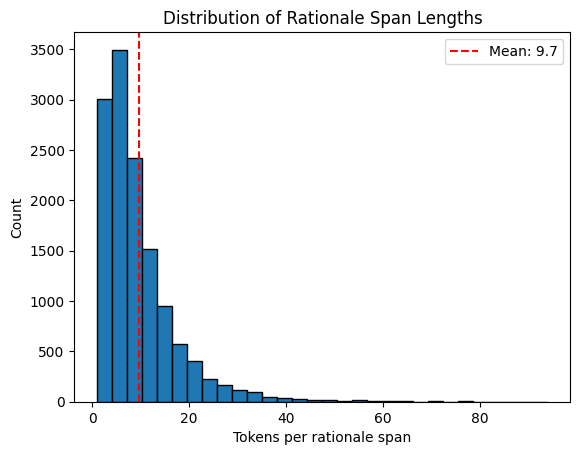

In [ ]:
# Check average rationale length
rationale_lengths = []

for idx, row in df.iterrows():
    rationale_cols = [
        'annotator1_moralA_rationales', 'annotator1_moralB_rationales', 'annotator1_moralC_rationales',
        'annotator2_moralA_rationales', 'annotator2_moralB_rationales', 'annotator2_moralC_rationales'
    ]

    for col in rationale_cols:
        val = row[col]
        if pd.notna(val) and val != '0' and val != 0:
            spans = str(val).split(';')
            for span in spans:
                span = span.strip()
                if span:
                    # Count tokens in span
                    num_tokens = len(tokenizer.tokenize(span))
                    rationale_lengths.append(num_tokens)

print(f"Total rationale spans: {len(rationale_lengths)}")
print(f"Average tokens per span: {np.mean(rationale_lengths):.2f}")
print(f"Median tokens per span: {np.median(rationale_lengths):.2f}")
print(f"Min: {np.min(rationale_lengths)}, Max: {np.max(rationale_lengths)}")
print(f"Std: {np.std(rationale_lengths):.2f}")

# Distribution
import matplotlib.pyplot as plt
plt.hist(rationale_lengths, bins=30, edgecolor='black')
plt.xlabel('Tokens per rationale span')
plt.ylabel('Count')
plt.title('Distribution of Rationale Span Lengths')
plt.axvline(np.mean(rationale_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(rationale_lengths):.1f}')
plt.legend()
plt.show()

In [ ]:
# Debug: Check actual probability values
# First load the model
checkpoint = torch.load('/content/drive/MyDrive/Rationale/model/bert_hatexplain_multilabel_lambda1.pt',
                        map_location=device, weights_only=False)

model = BertForMoralClassification.from_pretrained(
    config.MODEL_NAME,
    num_labels=config.NUM_LABELS
)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# Now debug
faithfulness_calc = FaithfulnessMetrics(
    model, tokenizer, device,
    top_k=10, threshold=config.THRESHOLD
)

# Get one sample
sample_batch = next(iter(test_loader))
input_ids = sample_batch['input_ids'][0]
attention_mask = sample_batch['attention_mask'][0]

# Get predictions
pred_classes = faithfulness_calc.get_predicted_classes(input_ids, attention_mask)
print(f"Predicted classes: {pred_classes}")
print(f"Predicted labels: {[config.ID2LABEL[i] for i in pred_classes]}")

# Original probability
orig_prob = faithfulness_calc.get_predicted_class_prob(input_ids, attention_mask, pred_classes)
print(f"\nOriginal prob: {orig_prob:.4f}")

# Get rationale indices (need to run evaluate first to get attentions)
# Or compute attention directly:
with torch.no_grad():
    outputs = model(
        input_ids=input_ids.unsqueeze(0).to(device),
        attention_mask=attention_mask.unsqueeze(0).to(device),
        output_attentions=True
    )
    attention_weights = outputs['attention'][0].cpu().numpy()

rationale_indices = faithfulness_calc.select_rationale_indices(
    attention_weights, attention_mask.numpy(), method='topk'
)
print(f"Rationale indices: {rationale_indices}")
print(f"Num rationale tokens: {len(rationale_indices)}")

# Show actual tokens selected as rationales
tokens = tokenizer.convert_ids_to_tokens(input_ids)
print(f"Rationale tokens: {[tokens[i] for i in rationale_indices]}")

# Comprehensiveness: mask rationales
masked_ids = faithfulness_calc.create_masked_input(input_ids, rationale_indices)
masked_prob = faithfulness_calc.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)
print(f"\nAfter removing rationales prob: {masked_prob:.4f}")
print(f"Comprehensiveness: {orig_prob - masked_prob:.4f}")

# Sufficiency: keep only rationales
rationale_set = set(rationale_indices.tolist())
indices_to_mask = []
for idx in range(len(input_ids)):
    token = tokenizer.convert_ids_to_tokens([input_ids[idx].item()])[0]
    if token in ['[CLS]', '[SEP]', '[PAD]']:
        continue
    if idx not in rationale_set:
        indices_to_mask.append(idx)

print(f"\nTokens to mask for sufficiency: {len(indices_to_mask)}")
masked_ids_suff = faithfulness_calc.create_masked_input(input_ids, indices_to_mask)
rationale_only_prob = faithfulness_calc.get_predicted_class_prob(masked_ids_suff, attention_mask, pred_classes)
print(f"Rationale-only prob: {rationale_only_prob:.4f}")
print(f"Sufficiency: {orig_prob - rationale_only_prob:.4f}")

Some weights of BertForMoralClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Predicted classes: []
Predicted labels: []

Original prob: 0.0000
Rationale indices: [ 7  6  8  9  5  3  4 10 13  2]
Num rationale tokens: 10
Rationale tokens: ['tomar', 'vai', 'no', 'c', '##ro', 'Bols', '##ona', '.', '[SEP]', '##i']

After removing rationales prob: 0.0000
Comprehensiveness: 0.0000

Tokens to mask for sufficiency: 3
Rationale-only prob: 0.0000
Sufficiency: 0.0000


In [ ]:
# Check actual probabilities for all classes
with torch.no_grad():
    outputs = model(
        input_ids=input_ids.unsqueeze(0).to(device),
        attention_mask=attention_mask.unsqueeze(0).to(device),
        output_attentions=False
    )
    probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()

print("Probabilities per class:")
for i, label in enumerate(config.LABELS):
    print(f"  {label}: {probs[i]:.4f}")

print(f"\nThreshold: {config.THRESHOLD}")
print(f"Max prob: {probs.max():.4f}")

# Also check the actual text
print(f"\nText: {tokenizer.decode(input_ids, skip_special_tokens=True)}")

# Check ground truth labels for this sample
print(f"Ground truth: {sample_batch['labels'][0].numpy()}")

Probabilities per class:
  Normal: 0.0041
  HN: 0.3175
  FN: 0.0002
  PN: 0.1172
  AN: 0.0233
  LN: 0.0100

Threshold: 0.5
Max prob: 0.3175

Text: Ei Bolsonaro vai tomar no c...
Ground truth: [0. 0. 0. 1. 0. 0.]


In [ ]:
# Check how many samples have no predictions above threshold
no_pred_count = 0
low_max_probs = []

for batch in test_loader:
    for i in range(batch['input_ids'].size(0)):
        input_ids = batch['input_ids'][i]
        attention_mask = batch['attention_mask'][i]

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids.unsqueeze(0).to(device),
                attention_mask=attention_mask.unsqueeze(0).to(device),
                output_attentions=False
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()

        max_prob = probs.max()
        low_max_probs.append(max_prob)

        if max_prob < config.THRESHOLD:
            no_pred_count += 1

print(f"Samples with no predictions (max prob < 0.5): {no_pred_count} / {len(low_max_probs)}")
print(f"Percentage: {100 * no_pred_count / len(low_max_probs):.1f}%")
print(f"\nMax prob distribution:")
print(f"  Min: {np.min(low_max_probs):.4f}")
print(f"  Max: {np.max(low_max_probs):.4f}")
print(f"  Mean: {np.mean(low_max_probs):.4f}")
print(f"  Median: {np.median(low_max_probs):.4f}")

Samples with no predictions (max prob < 0.5): 15 / 700
Percentage: 2.1%

Max prob distribution:
  Min: 0.0617
  Max: 0.9998
  Mean: 0.9652
  Median: 0.9981


In [ ]:
# Find a sample with predictions
for batch in test_loader:
    for i in range(batch['input_ids'].size(0)):
        input_ids = batch['input_ids'][i]
        attention_mask = batch['attention_mask'][i]

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids.unsqueeze(0).to(device),
                attention_mask=attention_mask.unsqueeze(0).to(device),
                output_attentions=True
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()
            attention_weights = outputs['attention'][0].cpu().numpy()

        pred_classes = np.where(probs > 0.5)[0]

        if len(pred_classes) > 0:  # Found one with predictions
            print(f"Text: {tokenizer.decode(input_ids, skip_special_tokens=True)[:100]}...")
            print(f"\nProbabilities:")
            for j, label in enumerate(config.LABELS):
                marker = "✓" if probs[j] > 0.5 else ""
                print(f"  {label}: {probs[j]:.4f} {marker}")

            print(f"\nPredicted: {[config.ID2LABEL[c] for c in pred_classes]}")
            print(f"Ground truth: {[config.ID2LABEL[j] for j, v in enumerate(batch['labels'][i].numpy()) if v == 1]}")

            # Now compute faithfulness for this sample
            rationale_indices = faithfulness_calc.select_rationale_indices(
                attention_weights, attention_mask.numpy(), method='topk'
            )
            tokens = tokenizer.convert_ids_to_tokens(input_ids)
            print(f"\nRationale tokens: {[tokens[idx] for idx in rationale_indices]}")

            orig_prob = probs[pred_classes].mean()
            print(f"\nOriginal prob: {orig_prob:.4f}")

            # Comprehensiveness
            masked_ids = faithfulness_calc.create_masked_input(input_ids, rationale_indices)
            masked_prob = faithfulness_calc.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)
            print(f"After removing rationales: {masked_prob:.4f}")
            print(f"Comprehensiveness: {orig_prob - masked_prob:.4f}")

            # Sufficiency
            rationale_set = set(rationale_indices.tolist())
            indices_to_mask = []
            for idx in range(len(input_ids)):
                token = tokens[idx]
                if token in ['[CLS]', '[SEP]', '[PAD]']:
                    continue
                if idx not in rationale_set:
                    indices_to_mask.append(idx)

            print(f"\nTotal tokens: {(attention_mask == 1).sum().item()}")
            print(f"Rationale tokens: {len(rationale_indices)}")
            print(f"Tokens masked for sufficiency: {len(indices_to_mask)}")

            masked_ids_suff = faithfulness_calc.create_masked_input(input_ids, indices_to_mask)
            rationale_only_prob = faithfulness_calc.get_predicted_class_prob(masked_ids_suff, attention_mask, pred_classes)
            print(f"Rationale-only prob: {rationale_only_prob:.4f}")
            print(f"Sufficiency: {orig_prob - rationale_only_prob:.4f}")

            break
    else:
        continue
    break

Text: @ kuka _ lucena Um ano sem picanha, sem cerveja, a abóbora encareceu e a geladeira vai a 5 barão, gá...

Probabilities:
  Normal: 0.9988 ✓
  HN: 0.0011 
  FN: 0.0009 
  PN: 0.0007 
  AN: 0.0010 
  LN: 0.0012 

Predicted: ['Normal']
Ground truth: ['FN', 'PN']

Rationale tokens: ['[SEP]', 'sem', 'ano', 'Um', ',', '##eceu', 'encar', '##j', '[UNK]', 'Can']

Original prob: 0.9988
After removing rationales: 0.9458
Comprehensiveness: 0.0530

Total tokens: 58
Rationale tokens: 10
Tokens masked for sufficiency: 47
Rationale-only prob: 0.0386
Sufficiency: 0.9602


In [ ]:
# Check average % of tokens that are rationales in your dataset
rationale_coverage = []

for idx, row in processed_df.iterrows():
    text = row['text']
    text_tokens = len(tokenizer.tokenize(text))

    ann1 = row['annotator1_rationales'] if isinstance(row['annotator1_rationales'], list) else []
    ann2 = row['annotator2_rationales'] if isinstance(row['annotator2_rationales'], list) else []
    all_rationales = ann1 + ann2

    if all_rationales and text_tokens > 0:
        rationale_tokens = sum(len(tokenizer.tokenize(r)) for r in all_rationales)
        # Divide by 2 since we have 2 annotators
        coverage = (rationale_tokens / 2) / text_tokens
        rationale_coverage.append(min(coverage, 1.0))

print(f"Average rationale coverage: {np.mean(rationale_coverage):.2%}")
print(f"Median rationale coverage: {np.median(rationale_coverage):.2%}")

Average rationale coverage: 75.46%
Median rationale coverage: 77.78%


In [ ]:
# update faithfulness
class FaithfulnessMetrics:
    """
    Compute Comprehensiveness and Sufficiency following ERASER benchmark.

    Reference: DeYoung et al. "ERASER: A Benchmark to Evaluate Rationalized NLP Models"
    https://arxiv.org/abs/1911.03429

    Comprehensiveness: p(y|x) - p(y|x \ r)
        - Remove rationale tokens, measure probability drop
        - Higher = rationales are important for prediction

    Sufficiency: p(y|x) - p(y|r)
        - Keep ONLY rationale tokens, measure probability drop
        - Lower = rationales alone are sufficient
    """

    def __init__(self, model, tokenizer, device, top_k=10, threshold=0.5, ratio=0.2):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.top_k = top_k
        self.threshold = threshold
        self.ratio = ratio
        print('I am here')

    # def select_rationale_indices(self, attention_weights, attention_mask, gt_attention=None, method='ratio'):
    #     """
    #     Methods:
    #     - 'topk': Fixed top-k tokens
    #     - 'ratio': Fixed percentage of tokens
    #     - 'adaptive': Match the number of GT rationale tokens (for fair comparison)
    #     """
    #     valid_attention = attention_weights.copy()
    #     valid_attention[attention_mask == 0] = -np.inf
    #     valid_attention[0] = -np.inf  # [CLS]

    #     seq_len = int(attention_mask.sum())
    #     valid_attention[seq_len - 1] = -np.inf  # [SEP]

    #     if method == 'adaptive' and gt_attention is not None:
    #         # Count how many tokens are marked as rationales in ground truth
    #         uniform_val = 1.0 / seq_len
    #         k = int((gt_attention > uniform_val * 1.5).sum())
    #         k = max(1, k)
    #     elif method == 'ratio':
    #         valid_count = seq_len - 2
    #         k = max(1, int(valid_count * self.ratio))
    #     else:  # topk
    #         k = self.top_k

    #     indices = valid_attention.argsort()[-k:][::-1]
    #     indices = [i for i in indices if valid_attention[i] > -np.inf]

    #     return np.array(indices)

    def select_rationale_indices(self, attention_weights, attention_mask, method='ratio'):
        """Select rationale tokens based on attention weights."""
        valid_attention = attention_weights.copy()
        valid_attention[attention_mask == 0] = -np.inf
        valid_attention[0] = -np.inf  # [CLS]

        # Find and exclude [SEP]
        seq_len = int(attention_mask.sum())
        valid_attention[seq_len - 1] = -np.inf  # [SEP]

        valid_count = seq_len - 2  # Exclude [CLS], [SEP]

        if method == 'ratio':
            k = max(1, int(valid_count * self.ratio))

        else:  # topk
            k = self.top_k

        indices = valid_attention.argsort()[-k:][::-1]
        indices = [i for i in indices if valid_attention[i] > -np.inf]

        return np.array(indices)

    def get_predicted_class_prob(self, input_ids, attention_mask, class_indices):
        """
        Get probability for specific class(es).
        For multi-label: returns mean prob across specified classes.
        """
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False  # Don't need attention here
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()

            if len(class_indices) == 0:
                return 0.0

            return probs[class_indices].mean()

    def get_predicted_classes(self, input_ids, attention_mask):
        """Get indices of predicted positive classes."""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids.unsqueeze(0).to(self.device),
                attention_mask=attention_mask.unsqueeze(0).to(self.device),
                output_attentions=False
            )
            probs = torch.sigmoid(outputs['logits'])[0].cpu().numpy()
            return np.where(probs > self.threshold)[0]

    def create_masked_input(self, input_ids, indices_to_mask):
        """Replace specified indices with [MASK] token."""
        masked_ids = input_ids.clone()
        for idx in indices_to_mask:
            if 0 <= idx < len(masked_ids):
                token = self.tokenizer.convert_ids_to_tokens([masked_ids[idx].item()])[0]
                if token not in ['[CLS]', '[SEP]', '[PAD]']:
                    masked_ids[idx] = self.tokenizer.mask_token_id
        return masked_ids

    def compute_comprehensiveness(self, input_ids, attention_mask, rationale_indices, pred_classes):
        """
        Comprehensiveness = p(y|x) - p(y|x \ r)

        Measures how much the prediction changes when rationales are REMOVED.
        Higher value = rationales are more important.
        """
        if len(pred_classes) == 0:
            return 0.0

        # p(y|x) - original probability
        original_prob = self.get_predicted_class_prob(input_ids, attention_mask, pred_classes)

        # p(y|x \ r) - probability after removing rationales
        masked_ids = self.create_masked_input(input_ids, rationale_indices)
        masked_prob = self.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)

        # Comprehensiveness = original - masked (should be positive if rationales matter)
        return float(original_prob - masked_prob)

    def compute_sufficiency(self, input_ids, attention_mask, rationale_indices, pred_classes):
        """
        Sufficiency = p(y|x) - p(y|r)

        Measures how sufficient the rationales alone are for prediction.
        Lower value = rationales alone are sufficient.
        """
        if len(pred_classes) == 0:
            return 0.0

        # p(y|x) - original probability
        original_prob = self.get_predicted_class_prob(input_ids, attention_mask, pred_classes)

        # p(y|r) - probability with ONLY rationales (mask everything else)
        rationale_set = set(rationale_indices.tolist() if hasattr(rationale_indices, 'tolist') else rationale_indices)

        # Find all non-special token indices to mask
        indices_to_mask = []
        for idx in range(len(input_ids)):
            token = self.tokenizer.convert_ids_to_tokens([input_ids[idx].item()])[0]
            if token in ['[CLS]', '[SEP]', '[PAD]']:
                continue
            if idx not in rationale_set:
                indices_to_mask.append(idx)

        masked_ids = self.create_masked_input(input_ids, indices_to_mask)
        rationale_only_prob = self.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)

        # Sufficiency = original - rationale_only (lower is better)
        return float(original_prob - rationale_only_prob)

    # def select_rationale_indices(self, attention_weights, attention_mask, method='topk'):
    #     """
    #     Select rationale token indices from attention weights.

    #     Methods:
    #     - 'topk': Select top-k highest attention tokens
    #     - 'threshold': Select tokens above mean + std attention
    #     """
    #     # Mask out padding tokens
    #     valid_attention = attention_weights.copy()
    #     valid_attention[attention_mask == 0] = -np.inf

    #     # Also ignore [CLS] (index 0) and [SEP] tokens for rationale selection
    #     valid_attention[0] = -np.inf  # [CLS]

    #     if method == 'topk':
    #         # Get top-k indices
    #         indices = valid_attention.argsort()[-self.top_k:][::-1]
    #         # Filter out any invalid indices
    #         indices = [i for i in indices if valid_attention[i] > -np.inf]
    #     else:  # threshold method
    #         threshold = valid_attention[valid_attention > -np.inf].mean() + \
    #                    valid_attention[valid_attention > -np.inf].std()
    #         indices = np.where(valid_attention > threshold)[0]

    #     return np.array(indices)

    def compute_all(self, data_loader, attentions):
        """
        Compute comprehensiveness and sufficiency over entire dataset.

        Args:
            data_loader: DataLoader with test data
            attentions: Model attention weights for each sample

        Returns:
            Dict with mean comprehensiveness and sufficiency scores
        """
        comp_scores = []
        suff_scores = []
        self.model.eval()
        idx = 0

        for batch in tqdm(data_loader, desc='Computing Faithfulness'):
            batch_size = batch['input_ids'].size(0)

            for i in range(batch_size):
                if idx >= len(attentions):
                    break

                input_ids = batch['input_ids'][i]
                attention_mask = batch['attention_mask'][i].numpy()
                attention_weights = attentions[idx]

                # Get predicted classes for this sample
                pred_classes = self.get_predicted_classes(input_ids, batch['attention_mask'][i])

                # Select rationale indices from attention
                rationale_indices = self.select_rationale_indices(
                    attention_weights, attention_mask, method='ratio'
                )

                # Skip if no rationales selected or no predictions
                if len(rationale_indices) == 0 or len(pred_classes) == 0:
                    idx += 1
                    continue

                # Compute metrics
                comp = self.compute_comprehensiveness(
                    input_ids, batch['attention_mask'][i], rationale_indices, pred_classes
                )
                suff = self.compute_sufficiency(
                    input_ids, batch['attention_mask'][i], rationale_indices, pred_classes
                )

                comp_scores.append(comp)
                suff_scores.append(suff)
                idx += 1

        return {
            'comprehensiveness': np.mean(comp_scores) if comp_scores else 0.0,
            'sufficiency': np.mean(suff_scores) if suff_scores else 0.0,
            'num_samples': len(comp_scores)
        }

In [ ]:
faithfulness_calc = FaithfulnessMetrics(
    model, tokenizer, device,
    top_k=10, threshold=config.THRESHOLD, ratio=0.75
)

# Test on same sample
rationale_indices = faithfulness_calc.select_rationale_indices(
    attention_weights, attention_mask.numpy(), method='ratio'
)

print(f"Total tokens: {(attention_mask == 1).sum().item()}")
print(f"Rationale tokens (75%): {len(rationale_indices)}")
print(f"Tokens masked for sufficiency: {58 - 2 - len(rationale_indices)}")  # -2 for CLS/SEP

NameError: name 'attention_weights' is not defined

In [ ]:
# Recompute with 75% ratio
orig_prob = probs[pred_classes].mean()
print(f"Original prob: {orig_prob:.4f}")

# Comprehensiveness (remove 42 rationale tokens)
masked_ids = faithfulness_calc.create_masked_input(input_ids, rationale_indices)
masked_prob = faithfulness_calc.get_predicted_class_prob(masked_ids, attention_mask, pred_classes)
print(f"After removing rationales: {masked_prob:.4f}")
print(f"Comprehensiveness: {orig_prob - masked_prob:.4f}")

# Sufficiency (mask only 14 tokens, keep 42)
rationale_set = set(rationale_indices.tolist())
indices_to_mask = []
for idx in range(len(input_ids)):
    token = tokenizer.convert_ids_to_tokens([input_ids[idx].item()])[0]
    if token in ['[CLS]', '[SEP]', '[PAD]']:
        continue
    if idx not in rationale_set:
        indices_to_mask.append(idx)

masked_ids_suff = faithfulness_calc.create_masked_input(input_ids, indices_to_mask)
rationale_only_prob = faithfulness_calc.get_predicted_class_prob(masked_ids_suff, attention_mask, pred_classes)
print(f"Rationale-only prob: {rationale_only_prob:.4f}")
print(f"Sufficiency: {orig_prob - rationale_only_prob:.4f}")

NameError: name 'probs' is not defined

In [ ]:
# Calculate average TOTAL rationale tokens per sample (excluding zeros)
total_rationale_tokens = []

for idx, row in processed_df.iterrows():
    ann1 = row['annotator1_rationales'] if isinstance(row['annotator1_rationales'], list) else []
    ann2 = row['annotator2_rationales'] if isinstance(row['annotator2_rationales'], list) else []

    # Count tokens from both annotators (then average)
    ann1_tokens = sum(len(tokenizer.tokenize(r)) for r in ann1) if ann1 else 0
    ann2_tokens = sum(len(tokenizer.tokenize(r)) for r in ann2) if ann2 else 0

    avg_tokens = (ann1_tokens + ann2_tokens) / 2 if (ann1 or ann2) else 0

    if avg_tokens > 0:  # Only include samples with rationales
        total_rationale_tokens.append(avg_tokens)

print(f"Samples with rationales: {len(total_rationale_tokens)}")
print(f"Average TOTAL rationale tokens per sample: {np.mean(total_rationale_tokens):.2f}")
print(f"Median: {np.median(total_rationale_tokens):.2f}")
print(f"Std: {np.std(total_rationale_tokens):.2f}")
print(f"Min: {np.min(total_rationale_tokens):.2f}, Max: {np.max(total_rationale_tokens):.2f}")

Samples with rationales: 3499
Average TOTAL rationale tokens per sample: 18.29
Median: 12.00
Std: 19.16
Min: 1.50, Max: 261.50


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BiRNNClassifier(nn.Module):
    """BiRNN with optional attention for multi-label classification."""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels,
                 use_attention=True, pretrained_embeddings=None):
        super().__init__()
        self.use_attention = use_attention

        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.rnn = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True,
                          batch_first=True, dropout=0.3, num_layers=1)
        self.dropout = nn.Dropout(0.3)

        if use_attention:
            self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, attention_mask=None, output_attentions=False, **kwargs):
        # Embed: (batch, seq) -> (batch, seq, embed_dim)
        embedded = self.embedding(input_ids)

        # Pack padded sequence for efficiency (optional but recommended)
        if attention_mask is not None:
            lengths = attention_mask.sum(dim=1).cpu()
            packed = nn.utils.rnn.pack_padded_sequence(
                embedded, lengths, batch_first=True, enforce_sorted=False
            )
            rnn_output, (hidden, cell) = self.rnn(packed)
            rnn_output, _ = nn.utils.rnn.pad_packed_sequence(rnn_output, batch_first=True)
        else:
            rnn_output, (hidden, cell) = self.rnn(embedded)

        rnn_output = self.dropout(rnn_output)  # (batch, seq, hidden*2)

        attention_weights = None

        if self.use_attention:
            # Compute attention scores
            attn_scores = self.attention(rnn_output).squeeze(-1)  # (batch, seq)

            # Mask padding
            if attention_mask is not None:
                attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)

            attention_weights = torch.softmax(attn_scores, dim=1)  # (batch, seq)

            # Weighted sum
            context = torch.bmm(attention_weights.unsqueeze(1), rnn_output).squeeze(1)  # (batch, hidden*2)
        else:
            # Max pooling over sequence
            if attention_mask is not None:
                mask_expanded = attention_mask.unsqueeze(-1).expand(rnn_output.size())
                rnn_output = rnn_output.masked_fill(mask_expanded == 0, -1e9)
            context, _ = torch.max(rnn_output, dim=1)  # (batch, hidden*2)

        # Classify
        logits = self.classifier(context)

        return {
            'logits': logits,
            'attention': attention_weights if (output_attentions and self.use_attention) else None
        }


class CNNClassifier(nn.Module):
    """CNN for multi-label text classification."""

    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes,
                 num_labels, pretrained_embeddings=None):
        super().__init__()

        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Multiple filter sizes (e.g., [3, 4, 5])
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(len(filter_sizes) * num_filters, num_labels)

    def forward(self, input_ids, attention_mask=None, output_attentions=False, **kwargs):
        # Embed: (batch, seq, embed_dim)
        embedded = self.embedding(input_ids)

        # Permute for conv1d: (batch, embed_dim, seq)
        embedded = embedded.permute(0, 2, 1)

        # Apply convolutions and ReLU
        conved = [torch.relu(conv(embedded)) for conv in self.convs]  # [(batch, filters, seq-fs+1)]

        # Max pooling
        pooled = [torch.max(conv, dim=2)[0] for conv in conved]  # [(batch, filters)]

        # Concatenate
        concat = torch.cat(pooled, dim=1)  # (batch, filters*len(filter_sizes))
        concat = self.dropout(concat)

        # Classify
        logits = self.classifier(concat)

        return {
            'logits': logits,
            'attention': None  # CNN doesn't produce attention
        }


class BoWClassifier(nn.Module):
    """Simple Bag-of-Words baseline for multi-label classification."""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels,
                 pretrained_embeddings=None):
        super().__init__()

        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, num_labels)

    def forward(self, input_ids, attention_mask=None, output_attentions=False, **kwargs):
        # Embed
        embedded = self.embedding(input_ids)  # (batch, seq, embed_dim)

        # Average pooling (bag of words)
        if attention_mask is not None:
            mask_expanded = attention_mask.unsqueeze(-1).expand(embedded.size())
            sum_embeddings = torch.sum(embedded * mask_expanded, dim=1)
            sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
            avg = sum_embeddings / sum_mask
        else:
            avg = torch.mean(embedded, dim=1)

        # Hidden layer
        hidden = torch.relu(self.fc1(avg))
        hidden = self.dropout(hidden)

        # Classify
        logits = self.classifier(hidden)

        return {
            'logits': logits,
            'attention': None
        }

In [ ]:
def load_glove_embeddings(glove_path, tokenizer, embedding_dim=300):
    """Load GloVe embeddings and create embedding matrix for tokenizer vocab."""

    print("Loading GloVe embeddings...")
    glove_dict = {}

    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Reading GloVe"):
            values = line.strip().split()

            # Skip malformed lines
            if len(values) < embedding_dim + 1:
                continue

            word = values[0]

            try:
                vector = np.asarray(values[1:], dtype='float32')

                # Verify correct dimension
                if len(vector) != embedding_dim:
                    continue

                glove_dict[word] = vector
            except ValueError:
                # Skip lines that can't be converted to float
                continue

    print(f"Loaded {len(glove_dict)} word vectors")

    # Create embedding matrix
    vocab_size = len(tokenizer.vocab)
    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    found = 0
    for word, idx in tokenizer.vocab.items():
        # Try exact match
        if word in glove_dict:
            embedding_matrix[idx] = glove_dict[word]
            found += 1
        # Try lowercase
        elif word.lower() in glove_dict:
            embedding_matrix[idx] = glove_dict[word.lower()]
            found += 1
        # Try without special characters
        elif word.strip('##') in glove_dict:
            embedding_matrix[idx] = glove_dict[word.strip('##')]
            found += 1
        else:
            # Random initialization for unknown words
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

    print(f"Found embeddings for {found}/{vocab_size} tokens ({100*found/vocab_size:.1f}%)")

    return torch.FloatTensor(embedding_matrix)


# Load embeddings
glove_embeddings = load_glove_embeddings(
    '/content/drive/MyDrive/Rationale/glove.840B.300d.txt',
    tokenizer,
    embedding_dim=300
)

Loading GloVe embeddings...


Reading GloVe: 0it [00:00, ?it/s]

KeyboardInterrupt: 

In [ ]:
def load_embeddings(path, tokenizer, embedding_dim):
    embeddings = {}

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        first_line = f.readline().strip().split()

        # Detect header: two numbers = vocab size + dim
        if len(first_line) == 2 and all(x.isdigit() for x in first_line):
            pass  # header consumed
        else:
            word = first_line[0]
            vec = list(map(float, first_line[1:]))
            if len(vec) == embedding_dim:
                embeddings[word] = vec

        for line in f:
            values = line.rstrip().split(" ")
            word = values[0]
            vec = list(map(float, values[1:]))
            if len(vec) == embedding_dim:
                embeddings[word] = vec

    # Build embedding matrix
    vocab_size = len(tokenizer.word_index) + 1
    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    for word, idx in tokenizer.word_index.items():
        if word in embeddings:
            embedding_matrix[idx] = embeddings[word]

    return embedding_matrix

pt_embeddings = load_embeddings(
    "/content/drive/MyDrive/Rationale/cc.pt.300.vec",
    tokenizer,
    embedding_dim=300
)


KeyboardInterrupt: 

In [ ]:
def load_embeddings_filtered(path, tokenizer, embedding_dim=300):
    """Load only embeddings for words in tokenizer vocab."""

    # Get vocab from BERT tokenizer
    vocab = set(tokenizer.vocab.keys())
    print(f"Tokenizer vocab size: {len(vocab)}")

    embeddings = {}
    found = 0

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        # Skip header if present
        first_line = f.readline().strip().split()
        if len(first_line) == 2 and first_line[0].isdigit():
            print(f"Header: {first_line[0]} words, {first_line[1]} dimensions")
        else:
            # First line is actual data
            word = first_line[0]
            if word in vocab and len(first_line) == embedding_dim + 1:
                try:
                    embeddings[word] = np.array(first_line[1:], dtype=np.float32)
                    found += 1
                except:
                    pass

        # Read rest of file
        for i, line in enumerate(tqdm(f, desc="Loading embeddings")):
            if i % 100000 == 0:
                print(f"Processed {i} lines, found {found} matches")

            # Early stop if we found all vocab words
            if found >= len(vocab):
                print("Found all vocab words!")
                break

            values = line.rstrip().split(" ", 1)  # Split only on first space
            if len(values) != 2:
                continue

            word = values[0]

            # Only load if word is in our vocab
            if word in vocab:
                try:
                    vec = np.array(values[1].split(), dtype=np.float32)
                    if len(vec) == embedding_dim:
                        embeddings[word] = vec
                        found += 1
                except:
                    continue

    print(f"Found {found}/{len(vocab)} vocab words in embeddings")

    # Build embedding matrix
    vocab_size = len(tokenizer.vocab)
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

    for word, idx in tokenizer.vocab.items():
        if word in embeddings:
            embedding_matrix[idx] = embeddings[word]
        elif word.lower() in embeddings:
            embedding_matrix[idx] = embeddings[word.lower()]
        else:
            # Random initialization for unknown words
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

    return torch.FloatTensor(embedding_matrix)


# Load filtered embeddings
pt_embeddings = load_embeddings_filtered(
    "/content/drive/MyDrive/Rationale/cc.pt.300.vec",
    tokenizer,
    embedding_dim=300
)

Tokenizer vocab size: 29794
Header: 2000000 words, 300 dimensions


Loading embeddings: 0it [00:00, ?it/s]

Processed 0 lines, found 0 matches
Processed 100000 lines, found 12914 matches
Processed 200000 lines, found 13576 matches
Processed 300000 lines, found 13993 matches
Processed 400000 lines, found 14276 matches
Processed 500000 lines, found 14514 matches
Processed 600000 lines, found 14691 matches
Processed 700000 lines, found 14818 matches
Processed 800000 lines, found 14945 matches
Processed 900000 lines, found 15064 matches
Processed 1000000 lines, found 15165 matches
Processed 1100000 lines, found 15251 matches
Processed 1200000 lines, found 15319 matches
Processed 1300000 lines, found 15380 matches
Processed 1400000 lines, found 15440 matches
Processed 1500000 lines, found 15484 matches
Processed 1600000 lines, found 15536 matches
Processed 1700000 lines, found 15573 matches
Processed 1800000 lines, found 15596 matches
Processed 1900000 lines, found 15631 matches
Found 15668/29794 vocab words in embeddings


In [ ]:
class GenericTrainer:
    """Generic trainer for non-attention-supervised models."""

    def __init__(self, model, device):
        self.model = model
        self.device = device

    def compute_loss(self, batch):
        """Compute multi-label classification loss."""
        input_ids = batch['input_ids'].to(self.device)
        attention_mask = batch['attention_mask'].to(self.device)
        labels = batch['labels'].to(self.device)

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=False
        )

        logits = outputs['logits']

        # Multi-label BCE loss
        loss_fn = nn.BCEWithLogitsLoss()
        loss = loss_fn(logits, labels)

        return loss, outputs


def train_epoch_generic(trainer, train_loader, optimizer, scheduler):
    """Train for one epoch."""
    trainer.model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()

        loss, outputs = trainer.compute_loss(batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Get predictions
        probs = torch.sigmoid(outputs['logits'])
        preds = (probs > 0.5).int().cpu().numpy()
        labels = batch['labels'].cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels)

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    avg_loss = total_loss / len(train_loader)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return {
        'loss': avg_loss,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro
    }


def evaluate_generic(trainer, val_loader):
    """Evaluate model."""
    trainer.model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_attentions = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating"):
            loss, outputs = trainer.compute_loss(batch)
            total_loss += loss.item()

            # Get predictions
            probs = torch.sigmoid(outputs['logits'])
            preds = (probs > 0.5).int().cpu().numpy()
            labels = batch['labels'].cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels)

            # Store attention if available
            if outputs['attention'] is not None:
                all_attentions.append(outputs['attention'].cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Flatten attentions if present
    if all_attentions:
        all_attentions = np.vstack(all_attentions)

    avg_loss = total_loss / len(val_loader)

    # Multi-label metrics
    exact_match = accuracy_score(all_labels, all_preds)
    hamming = hamming_loss(all_labels, all_preds)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_samples = f1_score(all_labels, all_preds, average='samples', zero_division=0)

    # AUROC
    try:
        auroc = roc_auc_score(all_labels, all_preds, average='macro')
    except:
        auroc = 0.0

    return {
        'loss': avg_loss,
        'exact_match': exact_match,
        'hamming_loss': hamming,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_samples': f1_samples,
        'auroc': auroc,
        'predictions': all_preds,
        'labels': all_labels,
        'attentions': all_attentions if all_attentions else None
    }


def train_model_generic(model, train_loader, val_loader, config, model_name="Model"):
    """Train a generic model (BiRNN, CNN, BoW)."""

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}\n")

    trainer = GenericTrainer(model, device)
    optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE,
                           weight_decay=config.WEIGHT_DECAY)

    total_steps = len(train_loader) * config.NUM_EPOCHS
    warmup_steps = int(total_steps * config.WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = {
        'train_loss': [], 'train_f1_micro': [], 'train_f1_macro': [],
        'val_loss': [], 'val_f1_micro': [], 'val_f1_macro': [],
        'val_exact_match': [], 'val_auroc': []
    }

    best_val_f1 = 0
    best_model_state = None
    patience_counter = 0

    for epoch in range(config.NUM_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{config.NUM_EPOCHS}")

        train_results = train_epoch_generic(trainer, train_loader, optimizer, scheduler)
        val_results = evaluate_generic(trainer, val_loader)

        print(f"Train - Loss: {train_results['loss']:.4f}, F1-micro: {train_results['f1_micro']:.4f}, F1-macro: {train_results['f1_macro']:.4f}")
        print(f"Val   - Loss: {val_results['loss']:.4f}, F1-micro: {val_results['f1_micro']:.4f}, F1-macro: {val_results['f1_macro']:.4f}")
        print(f"        Exact Match: {val_results['exact_match']:.4f}, Hamming: {val_results['hamming_loss']:.4f}, AUROC: {val_results['auroc']:.4f}")

        # Update history
        history['train_loss'].append(train_results['loss'])
        history['train_f1_micro'].append(train_results['f1_micro'])
        history['train_f1_macro'].append(train_results['f1_macro'])
        history['val_loss'].append(val_results['loss'])
        history['val_f1_micro'].append(val_results['f1_micro'])
        history['val_f1_macro'].append(val_results['f1_macro'])
        history['val_exact_match'].append(val_results['exact_match'])
        history['val_auroc'].append(val_results['auroc'])

        # Early stopping
        if val_results['f1_macro'] > best_val_f1:
            best_val_f1 = val_results['f1_macro']
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"  ↑ New best model (F1-macro: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{config.EARLY_STOPPING_PATIENCE})")

            if patience_counter >= config.EARLY_STOPPING_PATIENCE:
                print(f"\n⚠️ Early stopping triggered at epoch {epoch + 1}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return trainer, history

In [ ]:
class BiRNNClassifier(nn.Module):
    """BiRNN with optional attention for multi-label classification."""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels,
                 use_attention=True, pretrained_embeddings=None):
        super().__init__()
        self.use_attention = use_attention

        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.rnn = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True,
                          batch_first=True, num_layers=1)
        self.dropout = nn.Dropout(0.3)

        if use_attention:
            self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, attention_mask=None, output_attentions=False, **kwargs):
        batch_size, seq_len = input_ids.size()

        # Embed: (batch, seq) -> (batch, seq, embed_dim)
        embedded = self.embedding(input_ids)
        embedded = self.dropout(embedded)

        # BiRNN (without packing for simplicity)
        rnn_output, (hidden, cell) = self.rnn(embedded)  # (batch, seq, hidden*2)
        rnn_output = self.dropout(rnn_output)

        attention_weights = None

        if self.use_attention:
            # Compute attention scores
            attn_scores = self.attention(rnn_output).squeeze(-1)  # (batch, seq)

            # Mask padding
            if attention_mask is not None:
                attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)

            attention_weights = torch.softmax(attn_scores, dim=1)  # (batch, seq)

            # Weighted sum
            context = torch.bmm(attention_weights.unsqueeze(1), rnn_output).squeeze(1)  # (batch, hidden*2)
        else:
            # Max pooling over sequence
            if attention_mask is not None:
                mask_expanded = attention_mask.unsqueeze(-1).expand(rnn_output.size())
                rnn_output_masked = rnn_output.masked_fill(mask_expanded == 0, -1e9)
                context, _ = torch.max(rnn_output_masked, dim=1)
            else:
                context, _ = torch.max(rnn_output, dim=1)

        # Classify
        logits = self.classifier(context)

        return {
            'logits': logits,
            'attention': attention_weights if (output_attentions and self.use_attention) else None
        }

In [ ]:
# Reinitialize models
models = {}

# BiRNN with Attention
models['BiRNN-Attention'] = BiRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=config.NUM_LABELS,
    use_attention=True,
    pretrained_embeddings=pt_embeddings
).to(device)

# BiRNN without Attention (MaxPool)
models['BiRNN-MaxPool'] = BiRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=config.NUM_LABELS,
    use_attention=False,
    pretrained_embeddings=pt_embeddings
).to(device)

# CNN
models['CNN'] = CNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES,
    num_labels=config.NUM_LABELS,
    pretrained_embeddings=pt_embeddings
).to(device)

# BoW
models['BoW'] = BoWClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=config.NUM_LABELS,
    pretrained_embeddings=pt_embeddings
).to(device)

In [ ]:
# Model hyperparameters
VOCAB_SIZE = len(tokenizer.vocab)
EMBEDDING_DIM = 300
HIDDEN_DIM = 128
NUM_FILTERS = 100
FILTER_SIZES = [3, 4, 5]

# Initialize models
models = {}

# BiRNN with Attention
models['BiRNN-Attention'] = BiRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=config.NUM_LABELS,
    use_attention=True,
    pretrained_embeddings=pt_embeddings
).to(device)

# BiRNN without Attention (MaxPool)
models['BiRNN-MaxPool'] = BiRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=config.NUM_LABELS,
    use_attention=False,
    pretrained_embeddings=pt_embeddings
).to(device)

# CNN
models['CNN'] = CNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES,
    num_labels=config.NUM_LABELS,
    pretrained_embeddings=pt_embeddings
).to(device)

# BoW
models['BoW'] = BoWClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=config.NUM_LABELS,
    pretrained_embeddings=pt_embeddings
).to(device)

# Train all models
trainers = {}
histories = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}")
    print(f"{'='*60}\n")

    trainer, history = train_model_generic(
        model, train_loader, val_loader, config, model_name=name
    )

    trainers[name] = trainer
    histories[name] = history

    # Save model
    save_path = f'/content/drive/MyDrive/Rationale/model/{name.lower().replace("-", "_")}_2multilabel_lambda1.pt'
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config.__dict__,
        'history': history
    }, save_path)
    print(f"Model saved to {save_path}")


Training BiRNN-Attention


Training BiRNN-Attention


Epoch 1/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

NameError: name 'accuracy_score' is not defined

In [ ]:
class BiRNNClassifier(nn.Module):
    """BiRNN with optional attention for multi-label classification."""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels,
                 use_attention=True, pretrained_embeddings=None):
        super().__init__()
        self.use_attention = use_attention

        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.rnn = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True,
                          batch_first=True, num_layers=1)
        self.dropout = nn.Dropout(0.3)

        if use_attention:
            self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, attention_mask=None, output_attentions=False, **kwargs):
        device = input_ids.device
        batch_size, seq_len = input_ids.size()

        # Ensure attention_mask is on same device
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)

        # Embed: (batch, seq) -> (batch, seq, embed_dim)
        embedded = self.embedding(input_ids)
        embedded = self.dropout(embedded)

        # BiRNN
        rnn_output, (hidden, cell) = self.rnn(embedded)  # (batch, seq, hidden*2)
        rnn_output = self.dropout(rnn_output)

        attention_weights = None

        if self.use_attention:
            # Compute attention scores
            attn_scores = self.attention(rnn_output).squeeze(-1)  # (batch, seq)

            # Debug print
            # print(f"attn_scores shape: {attn_scores.shape}, attention_mask shape: {attention_mask.shape if attention_mask is not None else None}")

            # Mask padding - ensure shapes match
            if attention_mask is not None:
                # Truncate or pad attention_mask to match attn_scores
                if attention_mask.size(1) > attn_scores.size(1):
                    attention_mask = attention_mask[:, :attn_scores.size(1)]
                elif attention_mask.size(1) < attn_scores.size(1):
                    pad_size = attn_scores.size(1) - attention_mask.size(1)
                    attention_mask = F.pad(attention_mask, (0, pad_size), value=0)

                attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e9)

            attention_weights = torch.softmax(attn_scores, dim=1)  # (batch, seq)

            # Weighted sum
            context = torch.bmm(attention_weights.unsqueeze(1), rnn_output).squeeze(1)  # (batch, hidden*2)
        else:
            # Max pooling over sequence
            if attention_mask is not None:
                # Adjust mask size if needed
                if attention_mask.size(1) > rnn_output.size(1):
                    attention_mask = attention_mask[:, :rnn_output.size(1)]
                elif attention_mask.size(1) < rnn_output.size(1):
                    pad_size = rnn_output.size(1) - attention_mask.size(1)
                    attention_mask = F.pad(attention_mask, (0, pad_size), value=0)

                mask_expanded = attention_mask.unsqueeze(-1).expand(rnn_output.size())
                rnn_output_masked = rnn_output.masked_fill(mask_expanded == 0, -1e9)
                context, _ = torch.max(rnn_output_masked, dim=1)
            else:
                context, _ = torch.max(rnn_output, dim=1)

        # Classify
        logits = self.classifier(context)

        return {
            'logits': logits,
            'attention': attention_weights if (output_attentions and self.use_attention) else None
        }

In [ ]:
class GenericTrainer:
    """Generic trainer for non-attention-supervised models."""

    def __init__(self, model, device):
        self.model = model
        self.device = device

    def compute_loss(self, batch):
        """Compute multi-label classification loss."""
        input_ids = batch['input_ids'].to(self.device)
        attention_mask = batch['attention_mask'].to(self.device)  # Make sure this is moved to device
        labels = batch['labels'].to(self.device)

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=False
        )

        logits = outputs['logits']

        # Multi-label BCE loss
        loss_fn = nn.BCEWithLogitsLoss()
        loss = loss_fn(logits, labels)

        return loss, outputs

In [ ]:
# Quick debug - run one batch
model = models['BiRNN-Attention']
model.eval()

batch = next(iter(train_loader))
input_ids = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)

print(f"input_ids shape: {input_ids.shape}")
print(f"attention_mask shape: {attention_mask.shape}")

with torch.no_grad():
    embedded = model.embedding(input_ids)
    print(f"embedded shape: {embedded.shape}")

    rnn_output, _ = model.rnn(embedded)
    print(f"rnn_output shape: {rnn_output.shape}")

    attn_scores = model.attention(rnn_output).squeeze(-1)
    print(f"attn_scores shape: {attn_scores.shape}")

input_ids shape: torch.Size([16, 128])
attention_mask shape: torch.Size([16, 128])
embedded shape: torch.Size([16, 128, 300])
rnn_output shape: torch.Size([16, 128, 256])
attn_scores shape: torch.Size([16, 128])


In [ ]:
def train_epoch_generic(trainer, train_loader, optimizer, scheduler):
    """Train for one epoch."""
    trainer.model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()

        loss, outputs = trainer.compute_loss(batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Get predictions
        probs = torch.sigmoid(outputs['logits'])
        preds = (probs > 0.5).int().cpu().numpy()
        labels = batch['labels'].cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels)

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    avg_loss = total_loss / len(train_loader)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return {
        'loss': avg_loss,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro
    }

In [ ]:
# Direct test of training step
model = models['BiRNN-Attention']
model.train()

batch = next(iter(train_loader))

input_ids = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)
labels = batch['labels'].to(device)

print(f"input_ids: {input_ids.shape}, device: {input_ids.device}")
print(f"attention_mask: {attention_mask.shape}, device: {attention_mask.device}")
print(f"labels: {labels.shape}, device: {labels.device}")

# Forward pass
outputs = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    output_attentions=False
)

print(f"logits shape: {outputs['logits'].shape}")

# Loss
loss_fn = nn.BCEWithLogitsLoss()
loss = loss_fn(outputs['logits'], labels)
print(f"loss: {loss.item()}")

# Backward
loss.backward()
print("Backward pass successful!")

input_ids: torch.Size([16, 128]), device: cuda:0
attention_mask: torch.Size([16, 128]), device: cuda:0
labels: torch.Size([16, 6]), device: cuda:0
logits shape: torch.Size([16, 6])
loss: 0.6742123961448669
Backward pass successful!


In [ ]:
from sklearn.metrics import f1_score, accuracy_score, hamming_loss, roc_auc_score, classification_report
from transformers import get_linear_schedule_with_warmup

class GenericTrainer:
    """Generic trainer for non-attention-supervised models."""

    def __init__(self, model, device):
        self.model = model
        self.device = device

    def compute_loss(self, batch):
        """Compute multi-label classification loss."""
        input_ids = batch['input_ids'].to(self.device)
        attention_mask = batch['attention_mask'].to(self.device)
        labels = batch['labels'].to(self.device)

        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=False
        )

        logits = outputs['logits']

        # Multi-label BCE loss
        loss_fn = nn.BCEWithLogitsLoss()
        loss = loss_fn(logits, labels)

        return loss, outputs


def train_epoch_generic(trainer, train_loader, optimizer, scheduler):
    """Train for one epoch."""
    trainer.model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()

        loss, outputs = trainer.compute_loss(batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Get predictions
        probs = torch.sigmoid(outputs['logits'])
        preds = (probs > 0.5).int().cpu().numpy()
        labels = batch['labels'].cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels)

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    avg_loss = total_loss / len(train_loader)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return {
        'loss': avg_loss,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro
    }


def evaluate_generic(trainer, val_loader):
    """Evaluate model."""
    trainer.model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    all_attentions = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(trainer.device)
            attention_mask = batch['attention_mask'].to(trainer.device)
            labels = batch['labels'].to(trainer.device)

            outputs = trainer.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_attentions=True
            )

            logits = outputs['logits']

            # Loss
            loss_fn = nn.BCEWithLogitsLoss()
            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            # Get predictions
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int().cpu().numpy()

            all_preds.append(preds)
            all_labels.append(batch['labels'].numpy())
            all_probs.append(probs.cpu().numpy())

            # Store attention if available
            if outputs['attention'] is not None:
                all_attentions.append(outputs['attention'].cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    all_probs = np.vstack(all_probs)

    # Flatten attentions if present
    if all_attentions:
        all_attentions = np.vstack(all_attentions)
    else:
        all_attentions = None

    avg_loss = total_loss / len(val_loader)

    # Multi-label metrics
    exact_match = accuracy_score(all_labels, all_preds)
    hamming = hamming_loss(all_labels, all_preds)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_samples = f1_score(all_labels, all_preds, average='samples', zero_division=0)

    # AUROC
    try:
        auroc = roc_auc_score(all_labels, all_probs, average='macro')
    except:
        auroc = 0.0

    return {
        'loss': avg_loss,
        'exact_match': exact_match,
        'hamming_loss': hamming,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_samples': f1_samples,
        'auroc': auroc,
        'predictions': all_preds,
        'labels': all_labels,
        'attentions': all_attentions
    }


def train_model_generic(model, train_loader, val_loader, config, model_name="Model"):
    """Train a generic model (BiRNN, CNN, BoW)."""

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}\n")

    trainer = GenericTrainer(model, device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE,
                                  weight_decay=config.WEIGHT_DECAY)

    total_steps = len(train_loader) * config.NUM_EPOCHS
    warmup_steps = int(total_steps * config.WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = {
        'train_loss': [], 'train_f1_micro': [], 'train_f1_macro': [],
        'val_loss': [], 'val_f1_micro': [], 'val_f1_macro': [],
        'val_exact_match': [], 'val_auroc': []
    }

    best_val_f1 = 0
    best_model_state = None
    patience_counter = 0

    for epoch in range(config.NUM_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{config.NUM_EPOCHS}")

        train_results = train_epoch_generic(trainer, train_loader, optimizer, scheduler)
        val_results = evaluate_generic(trainer, val_loader)

        print(f"Train - Loss: {train_results['loss']:.4f}, F1-micro: {train_results['f1_micro']:.4f}, F1-macro: {train_results['f1_macro']:.4f}")
        print(f"Val   - Loss: {val_results['loss']:.4f}, F1-micro: {val_results['f1_micro']:.4f}, F1-macro: {val_results['f1_macro']:.4f}")
        print(f"        Exact Match: {val_results['exact_match']:.4f}, Hamming: {val_results['hamming_loss']:.4f}, AUROC: {val_results['auroc']:.4f}")

        # Update history
        history['train_loss'].append(train_results['loss'])
        history['train_f1_micro'].append(train_results['f1_micro'])
        history['train_f1_macro'].append(train_results['f1_macro'])
        history['val_loss'].append(val_results['loss'])
        history['val_f1_micro'].append(val_results['f1_micro'])
        history['val_f1_macro'].append(val_results['f1_macro'])
        history['val_exact_match'].append(val_results['exact_match'])
        history['val_auroc'].append(val_results['auroc'])

        # Early stopping
        if val_results['f1_macro'] > best_val_f1:
            best_val_f1 = val_results['f1_macro']
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"  ↑ New best model (F1-macro: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{config.EARLY_STOPPING_PATIENCE})")

            if patience_counter >= config.EARLY_STOPPING_PATIENCE:
                print(f"\n⚠️ Early stopping triggered at epoch {epoch + 1}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return trainer, history

In [ ]:
# Reinitialize models fresh
models = {}

models['BiRNN-Attention'] = BiRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=config.NUM_LABELS,
    use_attention=True,
    pretrained_embeddings=pt_embeddings
).to(device)

models['BiRNN-MaxPool'] = BiRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=config.NUM_LABELS,
    use_attention=False,
    pretrained_embeddings=pt_embeddings
).to(device)

models['CNN'] = CNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES,
    num_labels=config.NUM_LABELS,
    pretrained_embeddings=pt_embeddings
).to(device)

models['BoW'] = BoWClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=config.NUM_LABELS,
    pretrained_embeddings=pt_embeddings
).to(device)

# Train all
trainers = {}
histories = {}

for name, model in models.items():
    trainer, history = train_model_generic(
        model, train_loader, val_loader, config, model_name=name
    )

    trainers[name] = trainer
    histories[name] = history

    # Save model
    save_path = f'/content/drive/MyDrive/Rationale/model/{name.lower().replace("-", "_")}_3multilabel.pt'
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config.__dict__,
        'history': history
    }, save_path)
    print(f"Model saved to {save_path}")


Training BiRNN-Attention


Epoch 1/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train - Loss: 0.6920, F1-micro: 0.2968, F1-macro: 0.2015
Val   - Loss: 0.6726, F1-micro: 0.4168, F1-macro: 0.1346
        Exact Match: 0.4286, Hamming: 0.2152, AUROC: 0.6279
  ↑ New best model (F1-macro: 0.1346)

Epoch 2/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train - Loss: 0.4623, F1-micro: 0.4477, F1-macro: 0.1103
Val   - Loss: 0.4568, F1-micro: 0.4416, F1-macro: 0.1103
        Exact Match: 0.4943, Hamming: 0.2083, AUROC: 0.6631
  No improvement (4/5)

Epoch 6/20


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Train - Loss: 0.4388, F1-micro: 0.4407, F1-macro: 0.1094
Val   - Loss: 0.4418, F1-micro: 0.4419, F1-macro: 0.1104
        Exact Match: 0.4943, Hamming: 0.2081, AUROC: 0.6670
  No improvement (5/5)

⚠️ Early stopping triggered at epoch 6
Model saved to /content/drive/MyDrive/Rationale/model/bow_3multilabel.pt


In [ ]:
# Evaluate all models on test set
results = {}

for name, trainer in trainers.items():
    print(f"\n{'='*60}")
    print(f"Evaluating {name} on Test Set")
    print(f"{'='*60}\n")

    test_results = evaluate_generic(trainer, test_loader)

    print(f"Performance:")
    print(f"  Exact Match: {test_results['exact_match']:.4f}")
    print(f"  Hamming Loss: {test_results['hamming_loss']:.4f}")
    print(f"  F1-Micro: {test_results['f1_micro']:.4f}")
    print(f"  F1-Macro: {test_results['f1_macro']:.4f}")
    print(f"  F1-Samples: {test_results['f1_samples']:.4f}")
    print(f"  AUROC: {test_results['auroc']:.4f}")

    results[name] = test_results


Evaluating BiRNN-Attention on Test Set



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance:
  Exact Match: 0.4386
  Hamming Loss: 0.2038
  F1-Micro: 0.4391
  F1-Macro: 0.1536
  F1-Samples: 0.4610
  AUROC: 0.5855

Evaluating BiRNN-MaxPool on Test Set



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance:
  Exact Match: 0.4314
  Hamming Loss: 0.1905
  F1-Micro: 0.4302
  F1-Macro: 0.1110
  F1-Samples: 0.4314
  AUROC: 0.6086

Evaluating CNN on Test Set



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance:
  Exact Match: 0.3629
  Hamming Loss: 0.1579
  F1-Micro: 0.4461
  F1-Macro: 0.1748
  F1-Samples: 0.3736
  AUROC: 0.7283

Evaluating BoW on Test Set



Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Performance:
  Exact Match: 0.1371
  Hamming Loss: 0.4100
  F1-Micro: 0.3565
  F1-Macro: 0.1982
  F1-Samples: 0.3941
  AUROC: 0.5683


In [ ]:
import pandas as pd

# Create comparison table
comparison_data = []

for name, result in results.items():
    comparison_data.append({
        'Model': name,
        'F1-Macro': result['f1_macro'],
        'F1-Micro': result['f1_micro'],
        'Exact Match': result['exact_match'],
        'Hamming Loss': result['hamming_loss'],
        'AUROC': result['auroc']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1-Macro', ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv('/content/drive/MyDrive/Rationale/model_comparison2.csv', index=False)


MODEL COMPARISON
          Model  F1-Macro  F1-Micro  Exact Match  Hamming Loss    AUROC
            BoW  0.198239  0.356502     0.137143      0.410000 0.568289
            CNN  0.174827  0.446115     0.362857      0.157857 0.728350
BiRNN-Attention  0.153567  0.439056     0.438571      0.203810 0.585457
  BiRNN-MaxPool  0.110989  0.430199     0.431429      0.190476 0.608582


In [ ]:
# Portuguese RoBERTa models
MODEL_OPTIONS = {
    'bert': 'neuralmind/bert-base-portuguese-cased',
    'roberta': 'neuralmind/bert-large-portuguese-cased',  # Actually BERT-large
    'bertimbau': 'neuralmind/bert-base-portuguese-cased',

    # True RoBERTa for Portuguese:
    'roberta_pt': 'josu/roberta-pt-br',  # Brazilian Portuguese
    'xlm_roberta': 'xlm-roberta-base',   # Multilingual (includes Portuguese)
}

In [ ]:
from transformers import RobertaModel, RobertaPreTrainedModel, RobertaTokenizer

class RobertaForMoralClassification(RobertaPreTrainedModel):
    """RoBERTa with attention supervision for multi-label moral classification."""

    def __init__(self, config, num_labels=6):
        super().__init__(config)
        self.num_labels = num_labels
        self.roberta = RobertaModel(config, add_pooling_layer=True)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, num_labels)
        self.init_weights()

    def forward(self, input_ids, attention_mask=None, token_type_ids=None,
                output_attentions=True, return_dict=True):

        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,  # RoBERTa doesn't use this, but kept for compatibility
            output_attentions=output_attentions,
            return_dict=return_dict
        )

        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        # Extract CLS attention from last layer (same as BERT)
        cls_attention = None
        if output_attentions and outputs.attentions is not None:
            last_attention = outputs.attentions[-1]  # (batch, heads, seq, seq)
            cls_attention = last_attention[:, :, 0, :].mean(dim=1)  # (batch, seq)

        return {
            'logits': logits,
            'attention': cls_attention,
            'all_attentions': outputs.attentions if output_attentions else None
        }


# For XLM-RoBERTa (multilingual)
from transformers import XLMRobertaModel, XLMRobertaPreTrainedModel, XLMRobertaTokenizer

class XLMRobertaForMoralClassification(XLMRobertaPreTrainedModel):
    """XLM-RoBERTa with attention supervision for multi-label moral classification."""

    def __init__(self, config, num_labels=6):
        super().__init__(config)
        self.num_labels = num_labels
        self.roberta = XLMRobertaModel(config, add_pooling_layer=True)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, num_labels)
        self.init_weights()

    def forward(self, input_ids, attention_mask=None, token_type_ids=None,
                output_attentions=True, return_dict=True):

        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
            return_dict=return_dict
        )

        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        cls_attention = None
        if output_attentions and outputs.attentions is not None:
            last_attention = outputs.attentions[-1]
            cls_attention = last_attention[:, :, 0, :].mean(dim=1)

        return {
            'logits': logits,
            'attention': cls_attention,
            'all_attentions': outputs.attentions if output_attentions else None
        }

In [ ]:
# Option 1: XLM-RoBERTa (multilingual, includes Portuguese)
MODEL_NAME_ROBERTA = 'xlm-roberta-base'

# Load tokenizer
tokenizer_roberta = XLMRobertaTokenizer.from_pretrained(MODEL_NAME_ROBERTA)

# Initialize models
model_roberta_baseline = XLMRobertaForMoralClassification.from_pretrained(
    MODEL_NAME_ROBERTA,
    num_labels=config.NUM_LABELS
).to(device)

model_roberta_hatexplain = XLMRobertaForMoralClassification.from_pretrained(
    MODEL_NAME_ROBERTA,
    num_labels=config.NUM_LABELS
).to(device)

# Train with same functions as BERT
trainer_roberta, history_roberta = train_model(
    model_roberta_baseline, train_loader_roberta, val_loader_roberta, config,
    use_attention_loss=False, model_name="XLM-RoBERTa Baseline"
)

trainer_roberta_hx, history_roberta_hx = train_model(
    model_roberta_hatexplain, train_loader_roberta, val_loader_roberta, config,
    use_attention_loss=True, model_name="XLM-RoBERTa-HateXplain"
)

Some weights of XLMRobertaForMoralClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForMoralClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


NameError: name 'train_loader_roberta' is not defined